# Predicted-mask ROI retrieval

Each ROI is centered on the frozen model's predicted WT mask. Empty predictions use the configured image-foreground fallback, never ground truth. Reference tumor features are used for evaluation, not primary embedding ranking.

In [1]:
from pathlib import Path
import os
import sys
from functools import partial

_start = Path(os.environ.get("BRATS_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
PROJECT_ROOT = next(
    (p for p in (_start, *_start.parents) if (p / "src" / "brats_pipeline").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Place notebooks/ and src/ under one project root, or set BRATS_PROJECT_ROOT.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
from brats_pipeline.common import ProjectPaths
paths_io = ProjectPaths(PROJECT_ROOT)
resolve_existing_path = paths_io.resolve
print("Project:", PROJECT_ROOT)

Project: /home/mandrakedrink/projects/research_ts_bs


In [2]:
from brats_pipeline.common import seed_all, guard_output_directory
from brats_pipeline.data import (
    jp, load_nii as _load_nii, normalize_nonzero, remap_brats_labels,
    xyz_to_dhw, dhw_to_xyz, best_tumor_slice_dhw,
)
from brats_pipeline.inference import (
    create_segresnet, load_trusted_checkpoint, extract_model_state_dict,
    predict_labels_dhw, brats_region_dice_np, brats_region_voxels,
)
load_nii = partial(_load_nii, project_root=PROJECT_ROOT)
from brats_pipeline.data import (
    canonicalize_brats_labels as remap_brats_labels,
    axis_crop_pad_retrieval as axis_crop_pad,
    crop_patch_xyz_retrieval as crop_patch_xyz,
    tumor_center_xyz_retrieval as tumor_center_xyz,
    mask_center_xyz, image_foreground_center_xyz, euclidean_center_distance,
)
from brats_pipeline.retrieval import (
    l2_normalize_np, ensure_no_nan_matrix, encode_segresnet_features,
    pool_feature_map, extract_embedding_from_patch, load_encoder, compute_neighbors,
    mask_stats, compute_tumor_phenotype_features,
    bbox_sizes, compactness_proxy, centroid_or_nan, compute_tumor_features,
)
from brats_pipeline.common import save_dataframe as _save_dataframe, safe_display, save_json
set_seed = seed_all
l2_normalize_rows = l2_normalize_np
resolve_data_path = resolve_existing_path

In [3]:


import os
import json
import time
import random
import warnings
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import nibabel as nib

import torch
import torch.nn.functional as F

from monai.networks.nets import SegResNet
from monai.inferers import sliding_window_inference

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 260)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


## Configuration

In [4]:


CFG = {
    "project_root": str(PROJECT_ROOT),
    "manifest": str(PROJECT_ROOT / 'data/processed/manifest_4clients_seed42.csv'),

    # Final evaluation uses the test split.
    # Notebook 08 comparisons also require matching patient sets and phenotype definitions.
    "split_filter": ["test"],
    "max_cases": None,  # e.g. 4 for smoke test.

    "analysis_name": "08c_predicted_mask_roi_embedding_retrieval_test",
    "output_dir": "docs/08c_predicted_mask_roi_embedding_retrieval_test",

    "patch_size": (128, 128, 128),
    "num_classes": 4,
    "in_channels": 4,
    "init_filters": 32,
    "model_kwargs": {
        "spatial_dims": 3,
        "in_channels": 4,
        "out_channels": 4,
        "init_filters": 32,
        "blocks_down": (1, 2, 2, 4),
        "blocks_up": (1, 1, 1),
        "dropout_prob": 0.1,
    },

    # Sliding-window inference used to get predicted masks.
    "sw_roi_size": (128, 128, 128),
    "sw_batch_size": 1,
    "sw_overlap": 0.5,
    "sw_mode": "gaussian",
    "use_amp": True,

    # ROI localization from predicted WT.
    "roi_source": "predicted_wt_center",
    "fallback_if_no_pred_wt": "image_foreground_center",
    "allow_gt_fallback": False,

    # Encoder embedding.
    "embedding_method": "multiscale_gap_gmp",

    # Retrieval.
    # Primary learned space is "embedding".
    # "pred_tumor_features" and "hybrid_pred_features" use model-predicted masks, not GT masks.
    "top_k": [1, 3, 5, 10],
    "retrieval_spaces": ["embedding", "pred_tumor_features", "hybrid_pred_features"],
    "pred_feature_weight": 0.25,

    "reuse_existing_embeddings": False,
    "save_predicted_masks_npz": False,

    # Optional direct comparison with notebook 08 if the patient set matches.
    "gt_roi_08_table_dir": "docs/08_static_digital_twin_retrieval_test/tables",

    "experiments": [
        {
            "key": "centralized_s32_cew",
            "name": "Centralized SegResNet32 final CE-weighted — TEST",
            "short_name": "Centralized-S32",
            "checkpoint": "models/centralized_segresnet32_final/segresnet_final_best_mean_dice.pt",
            "enabled": True,
        },
        {
            "key": "fedavg_s32_cew",
            "name": "FedAvg SegResNet32 final CE-weighted — TEST",
            "short_name": "FedAvg-S32",
            "checkpoint": "models/federated_fedavg_segresnet32_final/fedavg_best_mean_dice.pt",
            "enabled": True,
        },
        {
            "key": "fedprox_s32_cew",
            "name": "FedProx SegResNet32 final CE-weighted — TEST",
            "short_name": "FedProx-S32",
            "checkpoint": "models/federated_fedprox_segresnet32_final/fedprox_best_mean_dice.pt",
            "enabled": True,
        },
    ],

    "random_seed": 42,
    "bootstrap_n": 1000,
}

PROJECT_ROOT = Path(CFG["project_root"]).expanduser().resolve()
OUT_DIR = PROJECT_ROOT / CFG["output_dir"]
TABLE_DIR = OUT_DIR / "tables"
FIGURE_DIR = OUT_DIR / "figures"
EMBED_DIR = OUT_DIR / "embeddings"
REPORT_DIR = OUT_DIR / "reports"
LOG_DIR = OUT_DIR / "logs"
PRED_DIR = OUT_DIR / "predictions"

for d in [OUT_DIR, TABLE_DIR, FIGURE_DIR, EMBED_DIR, REPORT_DIR, LOG_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = bool(CFG["use_amp"] and device.type == "cuda")

random.seed(CFG["random_seed"])
np.random.seed(CFG["random_seed"])
torch.manual_seed(CFG["random_seed"])

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)
print("split_filter:", CFG["split_filter"])
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
print("use_amp:", use_amp)
CFG

PROJECT_ROOT: /home/mandrakedrink/projects/research_ts_bs
OUT_DIR: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test
split_filter: ['test']
device: cuda
gpu: NVIDIA GeForce RTX 4090
use_amp: True


{'project_root': '/home/mandrakedrink/projects/research_ts_bs',
 'manifest': '/home/mandrakedrink/projects/research_ts_bs/data/processed/manifest_4clients_seed42.csv',
 'split_filter': ['test'],
 'max_cases': None,
 'analysis_name': '08c_predicted_mask_roi_embedding_retrieval_test',
 'output_dir': 'docs/08c_predicted_mask_roi_embedding_retrieval_test',
 'patch_size': (128, 128, 128),
 'num_classes': 4,
 'in_channels': 4,
 'init_filters': 32,
 'model_kwargs': {'spatial_dims': 3,
  'in_channels': 4,
  'out_channels': 4,
  'init_filters': 32,
  'blocks_down': (1, 2, 2, 4),
  'blocks_up': (1, 1, 1),
  'dropout_prob': 0.1},
 'sw_roi_size': (128, 128, 128),
 'sw_batch_size': 1,
 'sw_overlap': 0.5,
 'sw_mode': 'gaussian',
 'use_amp': True,
 'roi_source': 'predicted_wt_center',
 'fallback_if_no_pred_wt': 'image_foreground_center',
 'allow_gt_fallback': False,
 'embedding_method': 'multiscale_gap_gmp',
 'top_k': [1, 3, 5, 10],
 'retrieval_spaces': ['embedding',
  'pred_tumor_features',
  'hybri

In [5]:
def safe_display(title, df, n=20):
    display(Markdown(f"### {title}"))
    if isinstance(df, pd.DataFrame):
        display(df.head(n))
    else:
        display(df)

save_dataframe = partial(_save_dataframe, table_dir=TABLE_DIR)


## Evaluation cohort

In [6]:


manifest_path = resolve_existing_path(CFG["manifest"], required=True, label="manifest")
mf_df = pd.read_csv(manifest_path)

required_cols = {"patient_id", "client_domain", "split", "paths"}
missing = required_cols - set(mf_df.columns)
if missing:
    raise ValueError(f"Manifest missing required columns: {missing}")

eval_df = mf_df[mf_df["split"].isin(CFG["split_filter"])].copy()
eval_df = eval_df.sort_values(["client_domain", "patient_id"]).reset_index(drop=True)

if CFG["max_cases"] is not None:
    eval_df = eval_df.head(int(CFG["max_cases"])).copy()

safe_display(
    "Selected evaluation split counts",
    eval_df.groupby(["client_domain", "split"]).size().reset_index(name="n"),
)
save_dataframe(eval_df[["patient_id", "client_domain", "split"]], "01_eval_patient_list")

print("n_eval:", len(eval_df))
if len(eval_df) == 0:
    raise RuntimeError("No evaluation cases selected. Check CFG['split_filter'].")

if CFG["split_filter"] != ["test"]:
    display(Markdown("⚠️ **Not a final test run.** For final paper reporting, set `CFG['split_filter'] = ['test']`."))

### Selected evaluation split counts

,client_domain,split,n
0,TCGA-GBM,test,20
1,TCGA-LGG,test,13
2,UCSF-PDGM,test,76
3,UPENN-GBM,test,102


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/01_eval_patient_list.csv
n_eval: 211


## Frozen checkpoints

In [7]:


enabled_experiments = []
artifact_rows = []

for exp in CFG["experiments"]:
    if not exp.get("enabled", True):
        continue

    ckpt_path = resolve_existing_path(exp["checkpoint"], required=True, label=f"{exp['key']} checkpoint")
    exp = dict(exp)
    exp["checkpoint_resolved"] = str(ckpt_path)
    enabled_experiments.append(exp)

    artifact_rows.append({
        "key": exp["key"],
        "name": exp["name"],
        "checkpoint": exp["checkpoint"],
        "checkpoint_resolved": str(ckpt_path),
    })

artifact_df = pd.DataFrame(artifact_rows)
safe_display("Resolved checkpoints", artifact_df, n=10)
save_dataframe(artifact_df, "02_resolved_checkpoints")

if len(enabled_experiments) == 0:
    raise RuntimeError("No enabled experiments.")

### Resolved checkpoints

,key,name,checkpoint,checkpoint_resolved
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,models/centralized_segresnet32_final/segresnet...,/home/mandrakedrink/projects/research_ts_bs/mo...
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,models/federated_fedavg_segresnet32_final/feda...,/home/mandrakedrink/projects/research_ts_bs/mo...
2,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,models/federated_fedprox_segresnet32_final/fed...,/home/mandrakedrink/projects/research_ts_bs/no...


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/02_resolved_checkpoints.csv


## Case loading

In [8]:


def load_case_from_manifest_row(row):
    p = jp(row["paths"])

    images = []
    for m in ["t1", "t1ce", "t2", "flair"]:
        vol = load_nii(p[m], dtype=np.float32)
        vol = normalize_nonzero(vol)
        images.append(vol)

    image_xyz = np.stack(images, axis=0).astype(np.float32)

    seg_xyz = load_nii(p["seg"], dtype=np.uint8)
    seg_xyz = remap_brats_labels(seg_xyz)

    return {
        "patient_id": str(row["patient_id"]),
        "client_domain": row["client_domain"],
        "split": row["split"],
        "image_xyz": image_xyz,
        "seg_xyz": seg_xyz,
    }

## Reference phenotype features

Fractions use the nonzero image foreground; centroids and box sizes use voxel coordinates. This schema differs from the full-array definition used in notebook 08.

In [9]:


feature_rows = []
roi_reference_rows = []

t0 = time.time()
for i, row in eval_df.iterrows():
    case = load_case_from_manifest_row(row)
    feature_rows.append(compute_tumor_features(case))

    gt_wt_center = mask_center_xyz(case["seg_xyz"] > 0)
    image_center = image_foreground_center_xyz(case["image_xyz"])

    roi_reference_rows.append({
        "patient_id": case["patient_id"],
        "client_domain": case["client_domain"],
        "split": case["split"],
        "gt_wt_center_xyz": gt_wt_center,
        "image_foreground_center_xyz": image_center,
    })

    if (i + 1) % 25 == 0 or (i + 1) == len(eval_df):
        print(f"features [{i+1}/{len(eval_df)}] elapsed={time.time()-t0:.1f}s")

features_df = pd.DataFrame(feature_rows)
roi_reference_df = pd.DataFrame(roi_reference_rows)

safe_display("GT tumor phenotype features", features_df, n=5)
save_dataframe(features_df, "03_gt_tumor_phenotype_features")
save_dataframe(roi_reference_df, "04_gt_and_image_reference_centers")

features [25/211] elapsed=18.8s
features [50/211] elapsed=37.3s
features [75/211] elapsed=56.4s
features [100/211] elapsed=75.3s
features [125/211] elapsed=95.1s
features [150/211] elapsed=113.8s
features [175/211] elapsed=132.2s
features [200/211] elapsed=150.4s
features [211/211] elapsed=158.7s


### GT tumor phenotype features

,patient_id,client_domain,split,WT_vox,TC_vox,ET_vox,ED_vox,log1p_WT_vox,log1p_TC_vox,log1p_ET_vox,log1p_ED_vox,WT_fraction,TC_fraction,ET_fraction,ED_fraction,TC_to_WT_ratio,ET_to_WT_ratio,ET_to_TC_ratio,ED_to_WT_ratio,WT_centroid_x,WT_centroid_y,WT_centroid_z,TC_centroid_x,TC_centroid_y,TC_centroid_z,ET_centroid_x,ET_centroid_y,ET_centroid_z,WT_bbox_x,WT_bbox_y,WT_bbox_z,TC_bbox_x,TC_bbox_y,TC_bbox_z,ET_bbox_x,ET_bbox_y,ET_bbox_z,WT_compactness,TC_compactness,ET_compactness,ET_present
0,BraTS2021_00100,TCGA-GBM,test,95391,28513,25236,66878,11.465750,10.258150,10.136066,11.110640,0.073087,0.021846,0.019335,0.051241,0.298907,0.264553,0.885070,0.701093,145.0,112.0,96.0,142.0,110.0,91.0,142.0,110.0,91.0,52,79,68,42,32,62,42,32,62,0.341482,0.342178,0.302851,True
1,BraTS2021_00106,TCGA-GBM,test,227126,71071,48062,156055,12.333265,11.171449,10.780268,11.957970,0.146199,0.045748,0.030937,0.100451,0.312914,0.211609,0.676253,0.687086,93.0,116.0,97.0,104.0,95.0,97.0,104.0,97.0,94.0,77,116,77,48,69,61,47,69,60,0.330238,0.351781,0.247004,True
2,BraTS2021_00112,TCGA-GBM,test,91751,16834,9523,74917,11.426845,9.731215,9.161570,11.224149,0.060672,0.011132,0.006297,0.049540,0.183475,0.103792,0.565700,0.816525,159.0,169.0,65.0,158.0,186.0,58.0,158.0,186.0,56.0,55,86,65,39,65,44,33,39,44,0.298426,0.150923,0.168168,True
3,BraTS2021_00116,TCGA-GBM,test,169918,57508,47182,112410,12.043077,10.959697,10.761789,11.629917,0.110989,0.037564,0.030819,0.073425,0.338446,0.277675,0.820442,0.661554,90.0,160.0,73.0,86.0,165.0,64.0,87.0,165.0,64.0,65,89,94,49,60,71,49,60,71,0.312470,0.275501,0.226032,True
4,BraTS2021_00124,TCGA-GBM,test,176056,115839,39005,60217,12.078563,11.659965,10.571471,11.005727,0.115549,0.076028,0.025600,0.039522,0.657967,0.221549,0.336717,0.342033,153.0,126.0,68.0,153.0,127.0,68.0,150.0,122.0,65.0,78,105,70,55,80,61,55,80,53,0.307092,0.431591,0.167260,True


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/03_gt_tumor_phenotype_features.csv
saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/04_gt_and_image_reference_centers.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/04_gt_and_image_reference_centers.csv')

## Reference feature matrix

In [10]:


TUMOR_FEATURE_COLS = [
    "log1p_WT_vox", "log1p_TC_vox", "log1p_ET_vox", "log1p_ED_vox",
    "WT_fraction", "TC_fraction", "ET_fraction", "ED_fraction",
    "TC_to_WT_ratio", "ET_to_WT_ratio", "ET_to_TC_ratio", "ED_to_WT_ratio",
    "WT_centroid_x", "WT_centroid_y", "WT_centroid_z",
    "TC_centroid_x", "TC_centroid_y", "TC_centroid_z",
    "ET_centroid_x", "ET_centroid_y", "ET_centroid_z",
    "WT_bbox_x", "WT_bbox_y", "WT_bbox_z",
    "TC_bbox_x", "TC_bbox_y", "TC_bbox_z",
    "ET_bbox_x", "ET_bbox_y", "ET_bbox_z",
    "WT_compactness", "TC_compactness", "ET_compactness",
    "ET_present",
]
TUMOR_FEATURE_COLS = [c for c in TUMOR_FEATURE_COLS if c in features_df.columns]

feature_matrix_df = features_df[["patient_id"] + TUMOR_FEATURE_COLS].copy()

for c in TUMOR_FEATURE_COLS:
    if feature_matrix_df[c].dtype == bool:
        feature_matrix_df[c] = feature_matrix_df[c].astype(float)

feature_values = feature_matrix_df[TUMOR_FEATURE_COLS].astype(float)
feature_values = feature_values.replace([np.inf, -np.inf], np.nan)

medians = feature_values.median(axis=0, skipna=True).fillna(0.0)
feature_values_filled = feature_values.fillna(medians)

scaler = StandardScaler()
tumor_feature_z_raw = scaler.fit_transform(feature_values_filled).astype(np.float32)

# Keep the phenotype-distance scale consistent with notebook 08/08b:
# distance is computed in L2-normalized standardized GT tumor-feature space.
tumor_feature_z = l2_normalize_rows(tumor_feature_z_raw)

if not np.isfinite(tumor_feature_z).all():
    raise ValueError("tumor_feature_z contains non-finite values after median imputation and L2 normalization")

np.save(EMBED_DIR / "tumor_feature_z_raw.npy", tumor_feature_z_raw)
np.save(EMBED_DIR / "tumor_feature_z.npy", tumor_feature_z)
feature_matrix_df.to_csv(EMBED_DIR / "tumor_feature_raw_features.csv", index=False)

feature_scaler_meta = {
    "feature_cols": TUMOR_FEATURE_COLS,
    "medians": medians.to_dict(),
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
}
save_json(feature_scaler_meta, EMBED_DIR / "tumor_feature_scaler_meta.json")

print("tumor_feature_z shape:", tumor_feature_z.shape)
print("n feature columns:", len(TUMOR_FEATURE_COLS))
print(
    "tumor_feature_z normalized:",
    bool(np.allclose(np.linalg.norm(tumor_feature_z, axis=1), 1.0, atol=1e-5))
)

tumor_feature_z shape: (211, 34)
n feature columns: 34
tumor_feature_z normalized: True


## Encoder loading

In [11]:
def load_model_from_checkpoint(checkpoint_path, device):
    return load_encoder(checkpoint_path, device, model_kwargs=CFG["model_kwargs"])




def autocast_context():
    return torch.amp.autocast(
        "cuda",
        enabled=True
    ) if use_amp and device.type == "cuda" else nullcontext()

## Predicted-mask ROI policy

In [12]:


@torch.no_grad()
def predict_full_volume_seg_xyz(model, image_xyz):
    image_dhw = xyz_to_dhw(image_xyz)
    x = torch.from_numpy(image_dhw[None]).float().to(device)

    with autocast_context():
        logits = sliding_window_inference(
            inputs=x,
            roi_size=CFG["sw_roi_size"],
            sw_batch_size=CFG["sw_batch_size"],
            predictor=model,
            overlap=CFG["sw_overlap"],
            mode=CFG["sw_mode"],
        )

    pred_dhw = torch.argmax(logits, dim=1)[0].detach().cpu().numpy().astype(np.uint8)
    pred_xyz = dhw_to_xyz(pred_dhw)

    del x, logits
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pred_xyz


def choose_predicted_roi_center(case, pred_seg_xyz):
    pred_wt = pred_seg_xyz > 0
    gt_wt = case["seg_xyz"] > 0

    pred_center = mask_center_xyz(pred_wt)
    gt_center = mask_center_xyz(gt_wt)
    image_center = image_foreground_center_xyz(case["image_xyz"])

    if pred_center is not None:
        return pred_center, "predicted_wt_center", gt_center, image_center

    if CFG["allow_gt_fallback"]:
        return gt_center, "gt_wt_center_fallback_no_pred_wt", gt_center, image_center

    return image_center, "image_foreground_center_fallback_no_pred_wt", gt_center, image_center


def pred_region_volumes(pred_seg_xyz):
    WT = pred_seg_xyz > 0
    TC = (pred_seg_xyz == 1) | (pred_seg_xyz == 3)
    ET = pred_seg_xyz == 3
    return {
        "pred_WT_vox": int(WT.sum()),
        "pred_TC_vox": int(TC.sum()),
        "pred_ET_vox": int(ET.sum()),
    }

## Extract predicted-ROI embeddings

In [13]:
embedding_summary_rows = []
all_pred_roi_diag = []
all_pred_feature_frames = []
embeddings_by_exp = {}
expected_patient_ids = eval_df['patient_id'].astype(str).tolist()
for exp in enabled_experiments:
    key = exp['key']
    exp_name = exp['name']
    emb_path = EMBED_DIR / f'{key}_pred_roi_embeddings.npy'
    meta_path = EMBED_DIR / f'{key}_pred_roi_metadata.csv'
    diag_path = TABLE_DIR / f'05_{key}_pred_roi_diagnostics.csv'
    pred_feat_path = TABLE_DIR / f'05b_{key}_pred_tumor_features.csv'
    if CFG['reuse_existing_embeddings'] and emb_path.exists() and meta_path.exists() and diag_path.exists() and pred_feat_path.exists():
        print(f'reusing existing predicted-ROI embeddings for {key}')
        E = np.load(emb_path)
        meta_df = pd.read_csv(meta_path)
        diag_df = pd.read_csv(diag_path)
        pred_feat_df = pd.read_csv(pred_feat_path)
        meta_patient_ids = meta_df['patient_id'].astype(str).tolist()
        if meta_patient_ids != expected_patient_ids:
            raise ValueError(f"Existing embeddings for {key} do not match current eval_df patient order. Set CFG['reuse_existing_embeddings']=False and rerun.")
        if not set(meta_df['split'].astype(str)).issubset(set(CFG['split_filter'])):
            raise ValueError(f"Existing embeddings for {key} contain splits outside CFG['split_filter']. Set CFG['reuse_existing_embeddings']=False and rerun.")
        embeddings_by_exp[key] = {
            'E': E,
            'metadata': meta_df,
            'exp': exp,
            'diagnostics': diag_df,
            'pred_features': pred_feat_df
        }
        embedding_summary_rows.append({
            'key': key,
            'name': exp_name,
            'embedding_shape': list(E.shape),
            'embedding_path': str(emb_path),
            'metadata_path': str(meta_path),
            'diagnostics_path': str(diag_path),
            'pred_features_path': str(pred_feat_path),
            'reused': True
        })
        all_pred_roi_diag.append(diag_df)
        all_pred_feature_frames.append(pred_feat_df)
        continue
    print('=' * 80)
    print('Extracting predicted-ROI embeddings:', key, exp_name)
    model, model_meta = load_model_from_checkpoint(exp['checkpoint_resolved'], device)
    emb_rows = []
    meta_rows = []
    diag_rows = []
    pred_feature_rows = []
    t0 = time.time()
    for i, row in eval_df.iterrows():
        pid = str(row['patient_id'])
        case = load_case_from_manifest_row(row)
        pred_seg_xyz = predict_full_volume_seg_xyz(model, case['image_xyz'])
        roi_center, roi_source_used, gt_center, image_center = choose_predicted_roi_center(
            case,
            pred_seg_xyz
        )
        image_patch_xyz, seg_patch_xyz = crop_patch_xyz(
            case['image_xyz'],
            case['seg_xyz'],
            center_xyz=roi_center,
            patch_size=CFG['patch_size']
        )
        emb = extract_embedding_from_patch(
            model=model,
            image_patch_xyz=image_patch_xyz,
            device=device,
            method=CFG['embedding_method'],
            use_amp=use_amp
        )
        emb_rows.append(emb)
        vols = pred_region_volumes(pred_seg_xyz)
        gt_wt_vox = int((case['seg_xyz'] > 0).sum())
        gt_tc_vox = int(((case['seg_xyz'] == 1) | (case['seg_xyz'] == 3)).sum())
        gt_et_vox = int((case['seg_xyz'] == 3).sum())
        pred_feature_case = {
            'image_xyz': case['image_xyz'],
            'seg_xyz': pred_seg_xyz,
            'patient_id': pid,
            'client_domain': case['client_domain'],
            'split': case['split']
        }
        pred_feat = compute_tumor_features(pred_feature_case)
        pred_feat['experiment_key'] = key
        pred_feature_rows.append(pred_feat)
        meta_rows.append({
            'patient_id': pid,
            'client_domain': case['client_domain'],
            'split': case['split']
        })
        diag_rows.append({
            'experiment_key': key,
            'patient_id': pid,
            'client_domain': case['client_domain'],
            'split': case['split'],
            'roi_source_used': roi_source_used,
            'roi_center_x': roi_center[0],
            'roi_center_y': roi_center[1],
            'roi_center_z': roi_center[2],
            'gt_wt_center_x': gt_center[0] if gt_center is not None else np.nan,
            'gt_wt_center_y': gt_center[1] if gt_center is not None else np.nan,
            'gt_wt_center_z': gt_center[2] if gt_center is not None else np.nan,
            'image_foreground_center_x': image_center[0],
            'image_foreground_center_y': image_center[1],
            'image_foreground_center_z': image_center[2],
            'pred_to_gt_wt_center_distance': euclidean_center_distance(roi_center, gt_center),
            'gt_WT_vox': gt_wt_vox,
            'gt_TC_vox': gt_tc_vox,
            'gt_ET_vox': gt_et_vox,
            **vols,
            'pred_has_WT': bool(vols['pred_WT_vox'] > 0),
            'pred_has_ET': bool(vols['pred_ET_vox'] > 0),
            'gt_has_ET': bool(gt_et_vox > 0)
        })
        if CFG['save_predicted_masks_npz']:
            np.savez_compressed(PRED_DIR / f'{key}_{pid}_pred_seg_xyz.npz', pred_seg_xyz=pred_seg_xyz)
        if (i + 1) % 10 == 0 or i + 1 == len(eval_df):
            elapsed = time.time() - t0
            print(f'{key} [{i + 1}/{len(eval_df)}] pid={pid} roi={roi_source_used} elapsed={elapsed:.1f}s')
    E = np.stack(emb_rows, axis=0).astype(np.float32)
    meta_df = pd.DataFrame(meta_rows)
    diag_df = pd.DataFrame(diag_rows)
    pred_feat_df = pd.DataFrame(pred_feature_rows)
    np.save(emb_path, E)
    meta_df.to_csv(meta_path, index=False)
    diag_df.to_csv(diag_path, index=False)
    pred_feat_df.to_csv(pred_feat_path, index=False)
    embeddings_by_exp[key] = {
        'E': E,
        'metadata': meta_df,
        'exp': exp,
        'diagnostics': diag_df,
        'pred_features': pred_feat_df
    }
    all_pred_roi_diag.append(diag_df)
    all_pred_feature_frames.append(pred_feat_df)
    embedding_summary_rows.append({
        'key': key,
        'name': exp_name,
        'embedding_shape': list(E.shape),
        'embedding_path': str(emb_path),
        'metadata_path': str(meta_path),
        'diagnostics_path': str(diag_path),
        'pred_features_path': str(pred_feat_path),
        'reused': False,
        **model_meta
    })
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
embedding_summary_df = pd.DataFrame(embedding_summary_rows)
if 'algorithm' not in embedding_summary_df.columns:
    embedding_summary_df['algorithm'] = pd.NA
embedding_summary_df.loc[
    embedding_summary_df['key'].astype(str).str.contains('centralized', case=False, na=False),
    'algorithm'
] = embedding_summary_df.loc[
    embedding_summary_df['key'].astype(str).str.contains('centralized', case=False, na=False),
    'algorithm'
].fillna('Centralized')
embedding_summary_df.loc[
    embedding_summary_df['key'].astype(str).str.contains('fedavg', case=False, na=False),
    'algorithm'
] = embedding_summary_df.loc[
    embedding_summary_df['key'].astype(str).str.contains('fedavg', case=False, na=False),
    'algorithm'
].fillna('FedAvg')
embedding_summary_df.loc[
    embedding_summary_df['key'].astype(str).str.contains('fedprox', case=False, na=False),
    'algorithm'
] = embedding_summary_df.loc[
    embedding_summary_df['key'].astype(str).str.contains('fedprox', case=False, na=False),
    'algorithm'
].fillna('FedProx')
checkpoint_metadata_cols = [
    'epoch',
    'round',
    'best_round',
    'best_val_loss',
    'best_val_mean_dice',
    'algorithm',
    'fedprox_mu'
]
for col in checkpoint_metadata_cols:
    if col in embedding_summary_df.columns:
        embedding_summary_df[col] = embedding_summary_df[col].astype('object').where(
            pd.notna(embedding_summary_df[col]),
            'not_applicable'
        )
safe_display('Predicted-ROI embedding extraction summary', embedding_summary_df)
save_dataframe(embedding_summary_df, '05_pred_roi_embedding_extraction_summary')
pred_roi_diag_df = pd.concat(all_pred_roi_diag, ignore_index=True)
pred_tumor_features_df = pd.concat(all_pred_feature_frames, ignore_index=True)
gt_fallback_rows = pred_roi_diag_df['roi_source_used'].astype(str).str.contains(
    'gt_wt_center',
    case=False,
    regex=False
)
if not CFG['allow_gt_fallback'] and bool(gt_fallback_rows.any()):
    bad = pred_roi_diag_df.loc[gt_fallback_rows, ['experiment_key', 'patient_id', 'roi_source_used']]
    raise ValueError("GT fallback was used even though CFG['allow_gt_fallback'] is False. This would invalidate predicted-mask ROI evaluation.\n" + bad.head(20).to_string(index=False))
safe_display('Predicted ROI diagnostics', pred_roi_diag_df, n=10)
safe_display('Prediction-derived tumor features', pred_tumor_features_df, n=10)
save_dataframe(pred_roi_diag_df, '06_pred_roi_diagnostics_all')
save_dataframe(pred_tumor_features_df, '06b_pred_tumor_features_all')

Extracting predicted-ROI embeddings: centralized_s32_cew Centralized SegResNet32 final CE-weighted — TEST
centralized_s32_cew [10/211] pid=BraTS2021_01002 roi=predicted_wt_center elapsed=35.5s
centralized_s32_cew [20/211] pid=BraTS2021_01471 roi=predicted_wt_center elapsed=68.1s
centralized_s32_cew [30/211] pid=BraTS2021_01527 roi=predicted_wt_center elapsed=100.2s
centralized_s32_cew [40/211] pid=BraTS2021_00059 roi=predicted_wt_center elapsed=132.6s
centralized_s32_cew [50/211] pid=BraTS2021_00480 roi=predicted_wt_center elapsed=161.3s
centralized_s32_cew [60/211] pid=BraTS2021_00540 roi=predicted_wt_center elapsed=183.8s
centralized_s32_cew [70/211] pid=BraTS2021_00639 roi=predicted_wt_center elapsed=207.1s
centralized_s32_cew [80/211] pid=BraTS2021_00715 roi=predicted_wt_center elapsed=230.2s
centralized_s32_cew [90/211] pid=BraTS2021_00760 roi=predicted_wt_center elapsed=253.0s
centralized_s32_cew [100/211] pid=BraTS2021_01563 roi=predicted_wt_center elapsed=276.9s
centralized_s32

### Predicted-ROI embedding extraction summary

,key,name,embedding_shape,embedding_path,metadata_path,diagnostics_path,pred_features_path,reused,checkpoint,n_params,epoch,best_val_mean_dice,checkpoint_init_filters,checkpoint_patch_size,round,best_round,algorithm,fedprox_mu
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,"[211, 960]",/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,False,/home/mandrakedrink/projects/research_ts_bs/mo...,18798660,107.0,0.894972,32,"(128, 128, 128)",not_applicable,not_applicable,Centralized,not_applicable
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,"[211, 960]",/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,False,/home/mandrakedrink/projects/research_ts_bs/mo...,18798660,not_applicable,not_applicable,32,"(128, 128, 128)",120.0,120.0,FedAvg,not_applicable
2,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,"[211, 960]",/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,False,/home/mandrakedrink/projects/research_ts_bs/no...,18798660,not_applicable,not_applicable,32,"(128, 128, 128)",78.0,78.0,FedProx,0.001


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/05_pred_roi_embedding_extraction_summary.csv


### Predicted ROI diagnostics

,experiment_key,patient_id,client_domain,split,roi_source_used,roi_center_x,roi_center_y,roi_center_z,gt_wt_center_x,gt_wt_center_y,gt_wt_center_z,image_foreground_center_x,image_foreground_center_y,image_foreground_center_z,pred_to_gt_wt_center_distance,gt_WT_vox,gt_TC_vox,gt_ET_vox,pred_WT_vox,pred_TC_vox,pred_ET_vox,pred_has_WT,pred_has_ET,gt_has_ET
0,centralized_s32_cew,BraTS2021_00100,TCGA-GBM,test,predicted_wt_center,145,112,95,145,112,96,118,136,76,1.000000,95391,28513,25236,100140,27358,24290,True,True,True
1,centralized_s32_cew,BraTS2021_00106,TCGA-GBM,test,predicted_wt_center,94,115,96,93,116,97,119,138,72,1.732051,227126,71071,48062,244645,71046,56228,True,True,True
2,centralized_s32_cew,BraTS2021_00112,TCGA-GBM,test,predicted_wt_center,160,168,64,159,169,65,118,134,71,1.732051,91751,16834,9523,95827,27804,24090,True,True,True
3,centralized_s32_cew,BraTS2021_00116,TCGA-GBM,test,predicted_wt_center,91,159,73,90,160,73,120,134,70,1.414214,169918,57508,47182,159212,23233,21001,True,True,True
4,centralized_s32_cew,BraTS2021_00124,TCGA-GBM,test,predicted_wt_center,153,127,68,153,126,68,118,134,79,1.000000,176056,115839,39005,162300,124903,113290,True,True,True
5,centralized_s32_cew,BraTS2021_00138,TCGA-GBM,test,predicted_wt_center,81,148,70,82,148,71,118,135,73,1.414214,154118,20508,14523,164155,19767,14839,True,True,True
6,centralized_s32_cew,BraTS2021_00143,TCGA-GBM,test,predicted_wt_center,98,141,73,83,133,70,119,136,74,17.262677,162623,79535,63709,235762,85807,68811,True,True,True
7,centralized_s32_cew,BraTS2021_00144,TCGA-GBM,test,predicted_wt_center,78,127,57,79,128,57,118,136,76,1.414214,64347,44191,19458,74518,47858,23766,True,True,True
8,centralized_s32_cew,BraTS2021_00147,TCGA-GBM,test,predicted_wt_center,146,166,85,146,166,84,120,134,69,1.000000,175302,42239,36248,175020,38711,29453,True,True,True
9,centralized_s32_cew,BraTS2021_01002,TCGA-GBM,test,predicted_wt_center,161,145,65,159,144,65,118,135,77,2.236068,66802,36684,35019,73206,42521,37996,True,True,True


### Prediction-derived tumor features

,patient_id,client_domain,split,WT_vox,TC_vox,ET_vox,ED_vox,log1p_WT_vox,log1p_TC_vox,log1p_ET_vox,log1p_ED_vox,WT_fraction,TC_fraction,ET_fraction,ED_fraction,TC_to_WT_ratio,ET_to_WT_ratio,ET_to_TC_ratio,ED_to_WT_ratio,WT_centroid_x,WT_centroid_y,WT_centroid_z,TC_centroid_x,TC_centroid_y,TC_centroid_z,ET_centroid_x,ET_centroid_y,ET_centroid_z,WT_bbox_x,WT_bbox_y,WT_bbox_z,TC_bbox_x,TC_bbox_y,TC_bbox_z,ET_bbox_x,ET_bbox_y,ET_bbox_z,WT_compactness,TC_compactness,ET_compactness,ET_present,experiment_key
0,BraTS2021_00100,TCGA-GBM,test,100140,27358,24290,72782,11.514334,10.216801,10.097861,11.195238,0.076726,0.020961,0.018611,0.055764,0.273198,0.242560,0.887857,0.726802,145.0,112.0,95.0,142.0,110.0,91.0,142.0,110.0,91.0,52,76,69,41,30,53,41,30,53,0.367233,0.419666,0.372603,True,centralized_s32_cew
1,BraTS2021_00106,TCGA-GBM,test,244645,71046,56228,173599,12.407568,11.171097,10.937188,12.064509,0.157476,0.045732,0.036193,0.111744,0.290404,0.229835,0.791431,0.709596,94.0,115.0,96.0,104.0,95.0,97.0,105.0,95.0,96.0,78,117,77,48,66,65,48,66,65,0.348149,0.345017,0.273057,True,centralized_s32_cew
2,BraTS2021_00112,TCGA-GBM,test,95827,27804,24090,68023,11.470310,10.232971,10.089594,11.127616,0.063367,0.018386,0.015930,0.044982,0.290148,0.251391,0.866422,0.709852,160.0,168.0,64.0,165.0,171.0,58.0,166.0,171.0,58.0,106,92,101,106,74,81,106,74,81,0.097291,0.043761,0.037915,True,centralized_s32_cew
3,BraTS2021_00116,TCGA-GBM,test,159212,23233,21001,135979,11.977998,10.053372,9.952373,11.820263,0.103996,0.015176,0.013718,0.088820,0.145925,0.131906,0.903930,0.854075,91.0,159.0,73.0,91.0,161.0,62.0,91.0,161.0,63.0,69,87,93,39,54,61,39,54,61,0.285184,0.180849,0.163475,True,centralized_s32_cew
4,BraTS2021_00124,TCGA-GBM,test,162300,124903,113290,37397,11.997208,11.735301,11.637715,10.529373,0.106521,0.081977,0.074355,0.024544,0.769581,0.698028,0.907024,0.230419,153.0,127.0,68.0,153.0,126.0,68.0,152.0,127.0,68.0,62,85,68,55,80,62,55,80,62,0.452897,0.457856,0.415286,True,centralized_s32_cew
5,BraTS2021_00138,TCGA-GBM,test,164155,19767,14839,144388,12.008572,9.891820,9.605082,11.880266,0.110970,0.013363,0.010031,0.097607,0.120417,0.090396,0.750696,0.879583,81.0,148.0,70.0,70.0,156.0,54.0,70.0,155.0,54.0,73,109,83,46,44,35,46,44,35,0.248557,0.279037,0.209472,True,centralized_s32_cew
6,BraTS2021_00143,TCGA-GBM,test,235762,85807,68811,149955,12.370582,11.359868,11.139133,11.918097,0.163128,0.059372,0.047612,0.103757,0.363956,0.291866,0.801928,0.636044,98.0,141.0,73.0,79.0,124.0,61.0,77.0,123.0,62.0,127,136,94,110,94,53,109,94,53,0.145212,0.156576,0.126715,True,centralized_s32_cew
7,BraTS2021_00144,TCGA-GBM,test,74518,47858,23766,26660,11.218809,10.776014,10.076053,10.190957,0.052206,0.033528,0.016650,0.018677,0.642234,0.318930,0.496594,0.357766,78.0,127.0,57.0,78.0,130.0,58.0,78.0,130.0,57.0,50,80,51,42,58,44,42,58,44,0.365284,0.446503,0.221731,True,centralized_s32_cew
8,BraTS2021_00147,TCGA-GBM,test,175020,38711,29453,136309,12.072661,10.563905,10.290585,11.822687,0.112142,0.024804,0.018872,0.087338,0.221180,0.168284,0.760843,0.778820,146.0,166.0,85.0,140.0,171.0,84.0,140.0,170.0,84.0,69,87,92,36,53,43,36,53,43,0.316907,0.471832,0.358990,True,centralized_s32_cew
9,BraTS2021_01002,TCGA-GBM,test,73206,42521,37996,30685,11.201046,10.657777,10.545262,10.331562,0.053208,0.030906,0.027617,0.022303,0.580840,0.519028,0.893582,0.419160,161.0,145.0,65.0,166.0,148.0,63.0,166.0,148.0,63.0,47,67,52,46,52,52,46,52,52,0.447065,0.341853,0.305473,True,centralized_s32_cew


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/06_pred_roi_diagnostics_all.csv
saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/06b_pred_tumor_features_all.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/06b_pred_tumor_features_all.csv')

## Embedding integrity

In [14]:


integrity_rows = []

for key, obj in embeddings_by_exp.items():
    E = obj["E"]
    meta_df = obj["metadata"]

    meta_patient_ids = meta_df["patient_id"].astype(str).tolist()
    aligned = meta_patient_ids == expected_patient_ids

    integrity_rows.append({
        "experiment_key": key,
        "n_embeddings": E.shape[0],
        "embedding_dim": E.shape[1],
        "patient_order_aligned": aligned,
        "all_finite": bool(np.isfinite(E).all()),
        "mean_l2_norm": float(np.linalg.norm(E, axis=1).mean()),
        "min_l2_norm": float(np.linalg.norm(E, axis=1).min()),
        "max_l2_norm": float(np.linalg.norm(E, axis=1).max()),
    })

integrity_df = pd.DataFrame(integrity_rows)
safe_display("Predicted-ROI embedding integrity", integrity_df)
save_dataframe(integrity_df, "07_pred_roi_embedding_integrity")

if not integrity_df["patient_order_aligned"].all():
    raise ValueError("At least one experiment has embeddings not aligned with eval_df patient order.")

if not integrity_df["all_finite"].all():
    raise ValueError("At least one experiment has non-finite embeddings.")

### Predicted-ROI embedding integrity

,experiment_key,n_embeddings,embedding_dim,patient_order_aligned,all_finite,mean_l2_norm,min_l2_norm,max_l2_norm
0,centralized_s32_cew,211,960,True,True,1.0,1.0,1.0
1,fedavg_s32_cew,211,960,True,True,1.0,1.0,1.0
2,fedprox_s32_cew,211,960,True,True,1.0,1.0,1.0


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/07_pred_roi_embedding_integrity.csv


## Predicted phenotype features

In [15]:


patient_meta = eval_df[["patient_id", "client_domain", "split"]].copy()
patient_meta["patient_id"] = patient_meta["patient_id"].astype(str)

# GT-derived tumor_feature_z is kept for evaluation distances only.
# Prediction-derived tumor features are used for pred_tumor_features and hybrid_pred_features retrieval spaces.
gt_feature_z_by_index = tumor_feature_z.astype(np.float32)


def make_pred_feature_z(pred_feat_df, patient_meta, feature_cols):
    """Build standardized prediction-derived tumor features aligned to patient_meta."""
    pred_feat_df = pred_feat_df.copy()
    pred_feat_df["patient_id"] = pred_feat_df["patient_id"].astype(str)

    aligned = (
        pred_feat_df
        .drop_duplicates("patient_id")
        .set_index("patient_id")
        .loc[patient_meta["patient_id"].astype(str)]
        .reset_index()
    )

    cols = [c for c in feature_cols if c in aligned.columns]
    if len(cols) == 0:
        raise ValueError("No prediction-derived tumor feature columns were found.")

    Xdf = aligned[cols].copy()

    for c in cols:
        if Xdf[c].dtype == bool:
            Xdf[c] = Xdf[c].astype(float)

    Xdf = Xdf.astype(float).replace([np.inf, -np.inf], np.nan)
    med = Xdf.median(axis=0, skipna=True).fillna(0.0)
    Xfilled = Xdf.fillna(med)

    scaler = StandardScaler()
    Xz_raw = scaler.fit_transform(Xfilled).astype(np.float32)
    Xz_norm = l2_normalize_rows(Xz_raw)

    if not np.isfinite(Xz_raw).all():
        raise ValueError("Prediction-derived raw standardized feature matrix contains non-finite values.")
    if not np.isfinite(Xz_norm).all():
        raise ValueError("Prediction-derived L2-normalized feature matrix contains non-finite values.")

    return Xz_raw, Xz_norm, cols, med.to_dict(), scaler


retrieval_matrices = {}
pred_feature_meta_rows = []

for key, obj in embeddings_by_exp.items():
    E = l2_normalize_rows(obj["E"])

    (
        pred_feature_z_raw,
        pred_feature_z_norm,
        pred_feature_cols,
        pred_feature_medians,
        pred_feature_scaler,
    ) = make_pred_feature_z(
        obj["pred_features"],
        patient_meta,
        TUMOR_FEATURE_COLS,
    )

    pred_feature_raw_path = EMBED_DIR / f"{key}_pred_tumor_feature_z_raw.npy"
    pred_feature_norm_path = EMBED_DIR / f"{key}_pred_tumor_feature_z.npy"

    # Save both matrices explicitly:
    # - *_raw.npy: StandardScaler output for diagnostics.
    # - *.npy: L2-normalized standardized matrix actually used for pred_tumor_features retrieval.
    np.save(pred_feature_raw_path, pred_feature_z_raw)
    np.save(pred_feature_norm_path, pred_feature_z_norm)

    pred_feature_meta_rows.append({
        "experiment_key": key,
        "n_cases": int(pred_feature_z_norm.shape[0]),
        "n_features": int(pred_feature_z_norm.shape[1]),
        "feature_cols": json.dumps(pred_feature_cols),
        "feature_z_path": str(pred_feature_norm_path),
        "feature_z_raw_path": str(pred_feature_raw_path),
        "feature_z_is_l2_normalized": True,
        "retrieval_uses_l2_normalized_features": True,
    })

    spaces = {}
    if "embedding" in CFG["retrieval_spaces"]:
        spaces["embedding"] = E

    if "pred_tumor_features" in CFG["retrieval_spaces"]:
        spaces["pred_tumor_features"] = pred_feature_z_norm

    if "hybrid_pred_features" in CFG["retrieval_spaces"]:
        hybrid = np.concatenate(
            [E, float(CFG["pred_feature_weight"]) * pred_feature_z_norm],
            axis=1,
        )
        spaces["hybrid_pred_features"] = l2_normalize_rows(hybrid)

    retrieval_matrices[key] = spaces

pred_feature_meta_df = pd.DataFrame(pred_feature_meta_rows)
safe_display("Prediction-derived tumor feature matrices", pred_feature_meta_df)
save_dataframe(pred_feature_meta_df, "07_pred_tumor_feature_matrix_summary")

matrix_rows = []
for exp_key, spaces in retrieval_matrices.items():
    for space, X in spaces.items():
        matrix_rows.append({
            "experiment_key": exp_key,
            "retrieval_space": space,
            "n": X.shape[0],
            "dim": X.shape[1],
            "finite": bool(np.isfinite(X).all()),
        })

matrix_df = pd.DataFrame(matrix_rows)
safe_display("Retrieval matrix shapes", matrix_df)
save_dataframe(matrix_df, "08_retrieval_matrix_shapes")

### Prediction-derived tumor feature matrices

,experiment_key,n_cases,n_features,feature_cols,feature_z_path,feature_z_raw_path,feature_z_is_l2_normalized,retrieval_uses_l2_normalized_features
0,centralized_s32_cew,211,34,"[""log1p_WT_vox"", ""log1p_TC_vox"", ""log1p_ET_vox...",/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
1,fedavg_s32_cew,211,34,"[""log1p_WT_vox"", ""log1p_TC_vox"", ""log1p_ET_vox...",/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,True,True
2,fedprox_s32_cew,211,34,"[""log1p_WT_vox"", ""log1p_TC_vox"", ""log1p_ET_vox...",/home/mandrakedrink/projects/research_ts_bs/do...,/home/mandrakedrink/projects/research_ts_bs/do...,True,True


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/07_pred_tumor_feature_matrix_summary.csv


### Retrieval matrix shapes

,experiment_key,retrieval_space,n,dim,finite
0,centralized_s32_cew,embedding,211,960,True
1,centralized_s32_cew,pred_tumor_features,211,34,True
2,centralized_s32_cew,hybrid_pred_features,211,994,True
3,fedavg_s32_cew,embedding,211,960,True
4,fedavg_s32_cew,pred_tumor_features,211,34,True
5,fedavg_s32_cew,hybrid_pred_features,211,994,True
6,fedprox_s32_cew,embedding,211,960,True
7,fedprox_s32_cew,pred_tumor_features,211,34,True
8,fedprox_s32_cew,hybrid_pred_features,211,994,True


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/08_retrieval_matrix_shapes.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/08_retrieval_matrix_shapes.csv')

## Neighbor search and pair metrics

In [16]:


MAX_K = max(CFG["top_k"])

phenotype_lookup = features_df.set_index("patient_id").loc[patient_meta["patient_id"]].reset_index()
feature_z_by_index = gt_feature_z_by_index


def centroid_distance_from_features(q_feat, n_feat, prefix):
    cols = [f"{prefix}_centroid_x", f"{prefix}_centroid_y", f"{prefix}_centroid_z"]
    q = q_feat[cols].astype(float).values
    n = n_feat[cols].astype(float).values
    if np.isnan(q).any() or np.isnan(n).any():
        return np.nan
    return float(np.linalg.norm(q - n))


neighbor_rows = []

for exp_key, spaces in retrieval_matrices.items():
    exp_name = embeddings_by_exp[exp_key]["exp"]["name"]

    for space, X in spaces.items():
        nn_idx, nn_sim = compute_neighbors(X, MAX_K)

        for qi in range(X.shape[0]):
            q_meta = patient_meta.iloc[qi]
            q_feat = phenotype_lookup.iloc[qi]

            for rank in range(MAX_K):
                ni = int(nn_idx[qi, rank])
                n_meta = patient_meta.iloc[ni]
                n_feat = phenotype_lookup.iloc[ni]

                row = {
                    "experiment_key": exp_key,
                    "experiment_name": exp_name,
                    "retrieval_space": space,

                    "query_patient_id": q_meta["patient_id"],
                    "query_domain": q_meta["client_domain"],
                    "query_split": q_meta["split"],

                    "neighbor_rank": rank + 1,
                    "neighbor_patient_id": n_meta["patient_id"],
                    "neighbor_domain": n_meta["client_domain"],
                    "neighbor_split": n_meta["split"],
                    "cosine_similarity": float(nn_sim[qi, rank]),

                    "same_domain": bool(q_meta["client_domain"] == n_meta["client_domain"]),
                    "cross_domain": bool(q_meta["client_domain"] != n_meta["client_domain"]),

                    "query_ET_present": bool(q_feat["ET_present"]),
                    "neighbor_ET_present": bool(n_feat["ET_present"]),
                    "same_ET_presence": bool(q_feat["ET_present"] == n_feat["ET_present"]),
                }

                for region in ["WT", "TC", "ET"]:
                    row[f"query_log1p_{region}_vox"] = float(q_feat[f"log1p_{region}_vox"])
                    row[f"neighbor_log1p_{region}_vox"] = float(n_feat[f"log1p_{region}_vox"])
                    row[f"abs_log1p_{region}_diff"] = abs(
                        float(q_feat[f"log1p_{region}_vox"]) - float(n_feat[f"log1p_{region}_vox"])
                    )
                    row[f"{region}_centroid_distance"] = centroid_distance_from_features(
                        q_feat,
                        n_feat,
                        region
                    )

                row["tumor_feature_z_distance"] = float(np.linalg.norm(feature_z_by_index[qi] - feature_z_by_index[ni]))

                neighbor_rows.append(row)

neighbors_df = pd.DataFrame(neighbor_rows)
safe_display("Predicted-ROI top-k neighbor table", neighbors_df, n=10)
save_dataframe(neighbors_df, "09_pred_roi_topk_neighbors_long")

### Predicted-ROI top-k neighbor table

,experiment_key,experiment_name,retrieval_space,query_patient_id,query_domain,query_split,neighbor_rank,neighbor_patient_id,neighbor_domain,neighbor_split,cosine_similarity,same_domain,cross_domain,query_ET_present,neighbor_ET_present,same_ET_presence,query_log1p_WT_vox,neighbor_log1p_WT_vox,abs_log1p_WT_diff,WT_centroid_distance,query_log1p_TC_vox,neighbor_log1p_TC_vox,abs_log1p_TC_diff,TC_centroid_distance,query_log1p_ET_vox,neighbor_log1p_ET_vox,abs_log1p_ET_diff,ET_centroid_distance,tumor_feature_z_distance
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00100,TCGA-GBM,test,1,BraTS2021_01307,UPENN-GBM,test,0.981429,False,True,True,True,True,11.46575,12.078359,0.612609,23.895606,10.25815,10.691945,0.433794,31.160873,10.136066,10.457229,0.321163,30.016662,0.754348
1,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00100,TCGA-GBM,test,2,BraTS2021_01005,TCGA-GBM,test,0.978337,True,False,True,True,True,11.46575,11.583654,0.117904,61.644140,10.25815,10.637681,0.379530,56.462377,10.136066,10.449844,0.313778,56.258333,1.273346
2,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00100,TCGA-GBM,test,3,BraTS2021_00106,TCGA-GBM,test,0.977402,True,False,True,True,True,11.46575,12.333265,0.867515,52.163205,10.25815,11.171449,0.913298,41.291646,10.136066,10.780268,0.644201,40.274061,1.074382
3,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00100,TCGA-GBM,test,4,BraTS2021_00143,TCGA-GBM,test,0.975716,True,False,True,True,True,11.46575,11.999196,0.533446,70.434367,10.25815,11.283965,1.025815,72.587878,10.136066,11.062097,0.926030,73.484692,1.467069
4,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00100,TCGA-GBM,test,5,BraTS2021_00147,TCGA-GBM,test,0.975608,True,False,True,True,True,11.46575,12.074271,0.608521,55.326305,10.25815,10.651123,0.392972,61.432890,10.136066,10.498167,0.362101,60.440053,1.278342
5,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00100,TCGA-GBM,test,6,BraTS2021_00349,UPENN-GBM,test,0.973964,False,True,True,True,True,11.46575,11.417405,0.048345,73.437048,10.25815,10.506819,0.248669,68.029405,10.136066,10.279490,0.143423,68.007353,1.374629
6,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00100,TCGA-GBM,test,7,BraTS2021_01093,UPENN-GBM,test,0.972295,False,True,True,True,True,11.46575,11.972923,0.507173,38.574603,10.25815,10.616682,0.358532,45.617979,10.136066,10.516536,0.380469,45.617979,1.140044
7,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00100,TCGA-GBM,test,8,BraTS2021_01642,UCSF-PDGM,test,0.971871,False,True,True,True,True,11.46575,11.799299,0.333549,70.950687,10.25815,10.987714,0.729563,63.773035,10.136066,10.659750,0.523684,63.007936,1.385712
8,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00100,TCGA-GBM,test,9,BraTS2021_00483,UCSF-PDGM,test,0.970701,False,True,True,True,True,11.46575,12.072238,0.606488,60.671245,10.25815,10.718897,0.460746,57.454330,10.136066,10.323480,0.187414,57.454330,1.248146
9,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,embedding,BraTS2021_00100,TCGA-GBM,test,10,BraTS2021_00254,UPENN-GBM,test,0.969712,False,True,True,True,True,11.46575,11.499749,0.033999,74.926631,10.25815,10.360912,0.102762,78.134499,10.136066,10.099794,0.036272,77.278716,1.635235


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/09_pred_roi_topk_neighbors_long.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/09_pred_roi_topk_neighbors_long.csv')

## Query-level retrieval metrics

In [17]:


domain_counts = patient_meta["client_domain"].value_counts().to_dict()
N = len(patient_meta)

expected_same_by_pid = {}
for _, row in patient_meta.iterrows():
    domain = row["client_domain"]
    expected_same_by_pid[row["patient_id"]] = max(domain_counts[domain] - 1, 0) / max(N - 1, 1)

query_metric_rows = []

for (exp_key, space, query_id), g_all in neighbors_df.groupby(
    ["experiment_key", "retrieval_space", "query_patient_id"]
):
    q_domain = g_all["query_domain"].iloc[0]
    expected_same = expected_same_by_pid[query_id]

    for k in CFG["top_k"]:
        g = g_all[g_all["neighbor_rank"] <= int(k)].copy()
        if len(g) == 0:
            continue

        same_domain_rate = float(g["same_domain"].mean())

        query_metric_rows.append({
            "experiment_key": exp_key,
            "retrieval_space": space,
            "query_patient_id": query_id,
            "query_domain": q_domain,
            "k": int(k),
            "effective_k": int(len(g)),

            "same_domain_rate": same_domain_rate,
            "cross_domain_rate": 1.0 - same_domain_rate,
            "expected_same_domain_rate": float(expected_same),
            "same_domain_enrichment": float(same_domain_rate / expected_same) if expected_same > 0 else np.nan,

            "same_ET_presence_rate": float(g["same_ET_presence"].mean()),

            "mean_abs_log1p_WT_diff": float(g["abs_log1p_WT_diff"].mean()),
            "mean_abs_log1p_TC_diff": float(g["abs_log1p_TC_diff"].mean()),
            "mean_abs_log1p_ET_diff": float(g["abs_log1p_ET_diff"].mean()),

            "mean_tumor_feature_z_distance": float(g["tumor_feature_z_distance"].mean()),

            "mean_WT_centroid_distance": float(g["WT_centroid_distance"].mean(skipna=True)),
            "mean_TC_centroid_distance": float(g["TC_centroid_distance"].mean(skipna=True)),
            "mean_ET_centroid_distance": float(g["ET_centroid_distance"].mean(skipna=True)),
        })

query_metrics_df = pd.DataFrame(query_metric_rows)

overall_metrics_df = (
    query_metrics_df
    .groupby(["experiment_key", "retrieval_space", "k"])
    .agg(
        n_queries=("query_patient_id", "count"),
        same_domain_rate=("same_domain_rate", "mean"),
        cross_domain_rate=("cross_domain_rate", "mean"),
        expected_same_domain_rate=("expected_same_domain_rate", "mean"),
        same_domain_enrichment=("same_domain_enrichment", "mean"),
        same_ET_presence_rate=("same_ET_presence_rate", "mean"),
        mean_abs_log1p_WT_diff=("mean_abs_log1p_WT_diff", "mean"),
        mean_abs_log1p_TC_diff=("mean_abs_log1p_TC_diff", "mean"),
        mean_abs_log1p_ET_diff=("mean_abs_log1p_ET_diff", "mean"),
        mean_tumor_feature_z_distance=("mean_tumor_feature_z_distance", "mean"),
        mean_WT_centroid_distance=("mean_WT_centroid_distance", "mean"),
        mean_TC_centroid_distance=("mean_TC_centroid_distance", "mean"),
        mean_ET_centroid_distance=("mean_ET_centroid_distance", "mean"),
    )
    .reset_index()
)

safe_display("Predicted-ROI query-level retrieval metrics", query_metrics_df, n=10)
safe_display("Predicted-ROI overall retrieval metrics", overall_metrics_df, n=30)

save_dataframe(query_metrics_df, "10_pred_roi_query_level_retrieval_metrics")
save_dataframe(overall_metrics_df, "11_pred_roi_overall_retrieval_metrics")

### Predicted-ROI query-level retrieval metrics

,experiment_key,retrieval_space,query_patient_id,query_domain,k,effective_k,same_domain_rate,cross_domain_rate,expected_same_domain_rate,same_domain_enrichment,same_ET_presence_rate,mean_abs_log1p_WT_diff,mean_abs_log1p_TC_diff,mean_abs_log1p_ET_diff,mean_tumor_feature_z_distance,mean_WT_centroid_distance,mean_TC_centroid_distance,mean_ET_centroid_distance
0,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,1,1,1.000000,0.000000,0.357143,2.800000,1.0,0.563529,0.051649,0.116310,1.383567,71.728655,61.814238,60.448325
1,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,3,3,1.000000,0.000000,0.357143,2.800000,1.0,0.410187,0.272665,0.267342,1.252559,55.387226,51.527597,50.975504
2,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,5,5,1.000000,0.000000,0.357143,2.800000,1.0,0.339559,0.363907,0.412518,1.314176,60.061543,55.969122,55.285044
3,centralized_s32_cew,embedding,BraTS2021_00003,UCSF-PDGM,10,10,1.000000,0.000000,0.357143,2.800000,1.0,0.339148,0.434829,0.446080,1.272486,55.002396,51.380768,51.068349
4,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,1,1,0.000000,1.000000,0.357143,0.000000,1.0,0.197450,0.309717,0.200446,0.952534,78.930349,89.760793,90.055538
5,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,3,3,0.666667,0.333333,0.357143,1.866667,1.0,0.848262,0.808957,0.903649,0.963939,83.786886,80.522951,80.621200
6,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,5,5,0.600000,0.400000,0.357143,1.680000,1.0,0.953784,0.500035,0.587259,1.031779,89.222268,86.837385,86.934282
7,centralized_s32_cew,embedding,BraTS2021_00009,UCSF-PDGM,10,10,0.600000,0.400000,0.357143,1.680000,1.0,0.669766,0.706696,0.789949,1.016301,86.405974,83.504379,83.453950
8,centralized_s32_cew,embedding,BraTS2021_00014,UCSF-PDGM,1,1,1.000000,0.000000,0.357143,2.800000,1.0,0.703263,2.306873,2.095198,1.700257,78.108898,80.944425,80.081209
9,centralized_s32_cew,embedding,BraTS2021_00014,UCSF-PDGM,3,3,1.000000,0.000000,0.357143,2.800000,1.0,0.603609,1.726475,1.401844,1.137901,60.376046,62.282732,62.131128


### Predicted-ROI overall retrieval metrics

,experiment_key,retrieval_space,k,n_queries,same_domain_rate,cross_domain_rate,expected_same_domain_rate,same_domain_enrichment,same_ET_presence_rate,mean_abs_log1p_WT_diff,mean_abs_log1p_TC_diff,mean_abs_log1p_ET_diff,mean_tumor_feature_z_distance,mean_WT_centroid_distance,mean_TC_centroid_distance,mean_ET_centroid_distance
0,centralized_s32_cew,embedding,1,211,0.710900,0.289100,0.373234,2.721894,0.985782,0.558665,0.631052,0.716236,1.161023,52.320731,56.047388,56.282592
1,centralized_s32_cew,embedding,3,211,0.696682,0.303318,0.373234,2.564747,0.985782,0.551364,0.620771,0.711427,1.180892,53.310624,57.041894,57.136212
2,centralized_s32_cew,embedding,5,211,0.671090,0.328910,0.373234,2.430553,0.984834,0.571550,0.633022,0.754864,1.199993,54.061013,57.893023,58.130510
3,centralized_s32_cew,embedding,10,211,0.641232,0.358768,0.373234,2.153902,0.981991,0.581647,0.684206,0.831015,1.226408,54.478992,58.333258,58.592025
4,centralized_s32_cew,hybrid_pred_features,1,211,0.630332,0.369668,0.373234,2.290681,0.976303,0.331642,0.402853,0.590903,0.754069,28.133628,30.906625,30.594020
5,centralized_s32_cew,hybrid_pred_features,3,211,0.593997,0.406003,0.373234,2.128312,0.984202,0.363164,0.446365,0.560912,0.798050,30.751439,33.813966,33.795873
6,centralized_s32_cew,hybrid_pred_features,5,211,0.566825,0.433175,0.373234,1.986412,0.984834,0.381407,0.481505,0.599258,0.831090,31.915187,35.024476,34.949159
7,centralized_s32_cew,hybrid_pred_features,10,211,0.539336,0.460664,0.373234,1.799035,0.983412,0.413827,0.532402,0.676162,0.890346,35.150237,38.404582,38.365418
8,centralized_s32_cew,pred_tumor_features,1,211,0.393365,0.606635,0.373234,1.335152,0.985782,0.329359,0.451858,0.610336,0.668482,22.689867,25.468241,25.559980
9,centralized_s32_cew,pred_tumor_features,3,211,0.432859,0.567141,0.373234,1.414490,0.982622,0.356605,0.532129,0.679243,0.731921,24.239271,27.105923,27.174202


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/10_pred_roi_query_level_retrieval_metrics.csv
saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/11_pred_roi_overall_retrieval_metrics.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/11_pred_roi_overall_retrieval_metrics.csv')

## Cohort summaries

In [18]:


domain_metrics_df = (
    query_metrics_df
    .groupby(["experiment_key", "retrieval_space", "query_domain", "k"])
    .agg(
        n_queries=("query_patient_id", "count"),
        same_domain_rate=("same_domain_rate", "mean"),
        cross_domain_rate=("cross_domain_rate", "mean"),
        expected_same_domain_rate=("expected_same_domain_rate", "mean"),
        same_domain_enrichment=("same_domain_enrichment", "mean"),
        same_ET_presence_rate=("same_ET_presence_rate", "mean"),
        mean_abs_log1p_WT_diff=("mean_abs_log1p_WT_diff", "mean"),
        mean_abs_log1p_TC_diff=("mean_abs_log1p_TC_diff", "mean"),
        mean_abs_log1p_ET_diff=("mean_abs_log1p_ET_diff", "mean"),
        mean_tumor_feature_z_distance=("mean_tumor_feature_z_distance", "mean"),
    )
    .reset_index()
)

center_domain_df = (
    pred_roi_diag_df
    .groupby(["experiment_key", "client_domain"])
    .agg(
        n_cases=("patient_id", "count"),
        n_no_pred_wt=("pred_has_WT", lambda s: int((~s).sum())),
        no_pred_wt_rate=("pred_has_WT", lambda s: float((~s).mean())),
        mean_pred_to_gt_wt_center_distance=("pred_to_gt_wt_center_distance", "mean"),
        median_pred_to_gt_wt_center_distance=("pred_to_gt_wt_center_distance", "median"),
        pred_WT_median=("pred_WT_vox", "median"),
        gt_WT_median=("gt_WT_vox", "median"),
        pred_ET_median=("pred_ET_vox", "median"),
        gt_ET_median=("gt_ET_vox", "median"),
    )
    .reset_index()
)


center_overall_df = (
    pred_roi_diag_df
    .groupby(["experiment_key"])
    .agg(
        n_cases=("patient_id", "count"),
        n_no_pred_wt=("pred_has_WT", lambda s: int((~s).sum())),
        no_pred_wt_rate=("pred_has_WT", lambda s: float((~s).mean())),
        mean_pred_to_gt_wt_center_distance=("pred_to_gt_wt_center_distance", "mean"),
        median_pred_to_gt_wt_center_distance=("pred_to_gt_wt_center_distance", "median"),
        pred_WT_median=("pred_WT_vox", "median"),
        gt_WT_median=("gt_WT_vox", "median"),
        pred_ET_median=("pred_ET_vox", "median"),
        gt_ET_median=("gt_ET_vox", "median"),
    )
    .reset_index()
)

safe_display("Predicted-ROI domain-stratified retrieval metrics", domain_metrics_df, n=40)
safe_display("Predicted ROI center diagnostics overall", center_overall_df, n=20)
safe_display("Predicted ROI center diagnostics by domain", center_domain_df, n=40)

save_dataframe(domain_metrics_df, "12_pred_roi_domain_stratified_retrieval_metrics")
save_dataframe(center_overall_df, "13_pred_roi_center_diagnostics_overall")
save_dataframe(center_domain_df, "14_pred_roi_center_diagnostics_by_domain")

### Predicted-ROI domain-stratified retrieval metrics

,experiment_key,retrieval_space,query_domain,k,n_queries,same_domain_rate,cross_domain_rate,expected_same_domain_rate,same_domain_enrichment,same_ET_presence_rate,mean_abs_log1p_WT_diff,mean_abs_log1p_TC_diff,mean_abs_log1p_ET_diff,mean_tumor_feature_z_distance
0,centralized_s32_cew,embedding,TCGA-GBM,1,20,0.550000,0.450000,0.090476,6.078947,1.000000,0.428575,0.485038,0.480735,1.031010
1,centralized_s32_cew,embedding,TCGA-GBM,3,20,0.400000,0.600000,0.090476,4.421053,1.000000,0.486803,0.603920,0.545382,1.157493
2,centralized_s32_cew,embedding,TCGA-GBM,5,20,0.370000,0.630000,0.090476,4.089474,1.000000,0.493348,0.656005,0.598138,1.170323
3,centralized_s32_cew,embedding,TCGA-GBM,10,20,0.305000,0.695000,0.090476,3.371053,0.995000,0.520204,0.629358,0.608704,1.165771
4,centralized_s32_cew,embedding,TCGA-LGG,1,13,0.615385,0.384615,0.057143,10.769231,0.769231,0.579785,0.726064,2.439589,1.024599
5,centralized_s32_cew,embedding,TCGA-LGG,3,13,0.615385,0.384615,0.057143,10.769231,0.769231,0.658566,0.761504,2.304195,1.028887
6,centralized_s32_cew,embedding,TCGA-LGG,5,13,0.569231,0.430769,0.057143,9.961538,0.753846,0.768065,0.798922,2.846438,1.089176
7,centralized_s32_cew,embedding,TCGA-LGG,10,13,0.407692,0.592308,0.057143,7.134615,0.723077,0.808624,0.944801,3.351926,1.200253
8,centralized_s32_cew,embedding,UCSF-PDGM,1,76,0.736842,0.263158,0.357143,2.063158,1.000000,0.638911,0.622868,0.623251,1.200163
9,centralized_s32_cew,embedding,UCSF-PDGM,3,76,0.736842,0.263158,0.357143,2.063158,1.000000,0.613732,0.593156,0.593167,1.184810


### Predicted ROI center diagnostics overall

,experiment_key,n_cases,n_no_pred_wt,no_pred_wt_rate,mean_pred_to_gt_wt_center_distance,median_pred_to_gt_wt_center_distance,pred_WT_median,gt_WT_median,pred_ET_median,gt_ET_median
0,centralized_s32_cew,211,0,0.0,1.936510,1.414214,93549.0,87527.0,16678.0,15058.0
1,fedavg_s32_cew,211,0,0.0,2.468152,1.414214,92810.0,87527.0,16558.0,15058.0
2,fedprox_s32_cew,211,0,0.0,2.530070,1.414214,93863.0,87527.0,17015.0,15058.0


### Predicted ROI center diagnostics by domain

,experiment_key,client_domain,n_cases,n_no_pred_wt,no_pred_wt_rate,mean_pred_to_gt_wt_center_distance,median_pred_to_gt_wt_center_distance,pred_WT_median,gt_WT_median,pred_ET_median,gt_ET_median
0,centralized_s32_cew,TCGA-GBM,20,0,0.0,2.395319,1.414214,116306.5,118808.0,26327.5,32226.5
1,centralized_s32_cew,TCGA-LGG,13,0,0.0,1.934932,1.732051,101618.0,87527.0,1647.0,2093.0
2,centralized_s32_cew,UCSF-PDGM,76,0,0.0,2.209465,1.414214,101064.5,99270.5,22733.5,21519.0
3,centralized_s32_cew,UPENN-GBM,102,0,0.0,1.643370,1.000000,83572.5,74943.5,14599.0,13865.5
4,fedavg_s32_cew,TCGA-GBM,20,0,0.0,3.611192,1.732051,116933.0,118808.0,29329.5,32226.5
5,fedavg_s32_cew,TCGA-LGG,13,0,0.0,1.853418,1.414214,96814.0,87527.0,1562.0,2093.0
6,fedavg_s32_cew,UCSF-PDGM,76,0,0.0,2.813357,1.414214,100332.0,99270.5,21401.5,21519.0
7,fedavg_s32_cew,UPENN-GBM,102,0,0.0,2.065163,1.000000,86384.5,74943.5,15093.0,13865.5
8,fedprox_s32_cew,TCGA-GBM,20,0,0.0,4.153645,1.984059,117126.0,118808.0,32248.5,32226.5
9,fedprox_s32_cew,TCGA-LGG,13,0,0.0,1.739283,1.414214,102587.0,87527.0,3119.0,2093.0


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/12_pred_roi_domain_stratified_retrieval_metrics.csv
saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/13_pred_roi_center_diagnostics_overall.csv
saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/14_pred_roi_center_diagnostics_by_domain.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/14_pred_roi_center_diagnostics_by_domain.csv')

## Model comparisons

In [19]:
# The legacy feature schemas differ between 08 and 08c. Volume-error metrics
# remain on the same scale, but tumor-feature distances are not a pure ROI ablation.
print("Note: 08 and 08c use different phenotype schemas; interpret feature-distance deltas accordingly.")



gt_table_dir = resolve_existing_path(
    CFG["gt_roi_08_table_dir"],
    required=False,
    label="gt_roi_08_table_dir"
)
roi_comparison_df = None

if gt_table_dir is not None:
    gt_overall_path = gt_table_dir / "10_overall_retrieval_metrics.csv"
    gt_query_path = gt_table_dir / "09_query_level_retrieval_metrics.csv"

    if gt_overall_path.exists() and gt_query_path.exists():
        gt_overall_df = pd.read_csv(gt_overall_path)
        gt_query_df = pd.read_csv(gt_query_path)

        gt_patients = set(gt_query_df["query_patient_id"].astype(str).unique())
        pred_patients = set(query_metrics_df["query_patient_id"].astype(str).unique())

        if gt_patients == pred_patients:
            common_cols = [
                "experiment_key", "retrieval_space", "k",
                "same_domain_rate", "cross_domain_rate", "same_ET_presence_rate",
                "mean_abs_log1p_WT_diff", "mean_abs_log1p_TC_diff", "mean_abs_log1p_ET_diff",
                "mean_tumor_feature_z_distance",
            ]

            pred_small = overall_metrics_df[common_cols].copy()
            gt_small = gt_overall_df[common_cols].copy()

            roi_comparison_df = pred_small.merge(
                gt_small,
                on=["experiment_key", "retrieval_space", "k"],
                suffixes=("_pred_roi", "_gt_roi"),
                how="inner",
            )

            for metric in [
                "same_domain_rate",
                "cross_domain_rate",
                "same_ET_presence_rate",
                "mean_abs_log1p_WT_diff",
                "mean_abs_log1p_TC_diff",
                "mean_abs_log1p_ET_diff",
                "mean_tumor_feature_z_distance",
            ]:
                roi_comparison_df[f"{metric}_delta_pred_minus_gt"] = (
                    roi_comparison_df[f"{metric}_pred_roi"] - roi_comparison_df[f"{metric}_gt_roi"]
                )

            safe_display("Predicted ROI vs GT-centered ROI comparison", roi_comparison_df, n=40)
            save_dataframe(roi_comparison_df, "15_pred_roi_vs_gt_roi_overall_comparison")
        else:
            display(Markdown(
                "⚠️ Found notebook 08 outputs, but patient set does not match current split. "
                "Skipping direct predicted-vs-GT ROI comparison."
            ))
            print("n_gt_patients:", len(gt_patients), "n_pred_patients:", len(pred_patients))
    else:
        display(Markdown("GT-centered notebook 08 metric files were not found. Skipping direct ROI comparison."))
else:
    display(Markdown("GT-centered notebook 08 table directory was not resolved. Skipping direct ROI comparison."))

Note: 08 and 08c use different phenotype schemas; interpret feature-distance deltas accordingly.


### Predicted ROI vs GT-centered ROI comparison

,experiment_key,retrieval_space,k,same_domain_rate_pred_roi,cross_domain_rate_pred_roi,same_ET_presence_rate_pred_roi,mean_abs_log1p_WT_diff_pred_roi,mean_abs_log1p_TC_diff_pred_roi,mean_abs_log1p_ET_diff_pred_roi,mean_tumor_feature_z_distance_pred_roi,same_domain_rate_gt_roi,cross_domain_rate_gt_roi,same_ET_presence_rate_gt_roi,mean_abs_log1p_WT_diff_gt_roi,mean_abs_log1p_TC_diff_gt_roi,mean_abs_log1p_ET_diff_gt_roi,mean_tumor_feature_z_distance_gt_roi,same_domain_rate_delta_pred_minus_gt,cross_domain_rate_delta_pred_minus_gt,same_ET_presence_rate_delta_pred_minus_gt,mean_abs_log1p_WT_diff_delta_pred_minus_gt,mean_abs_log1p_TC_diff_delta_pred_minus_gt,mean_abs_log1p_ET_diff_delta_pred_minus_gt,mean_tumor_feature_z_distance_delta_pred_minus_gt
0,centralized_s32_cew,embedding,1,0.710900,0.289100,0.985782,0.558665,0.631052,0.716236,1.161023,0.758294,0.241706,0.985782,0.537291,0.586697,0.662412,1.148380,-0.047393,0.047393,0.000000e+00,0.021374,0.044355,0.053824,0.012643
1,centralized_s32_cew,embedding,3,0.696682,0.303318,0.985782,0.551364,0.620771,0.711427,1.180892,0.715640,0.284360,0.987362,0.553708,0.603054,0.694958,1.183833,-0.018957,0.018957,-1.579779e-03,-0.002343,0.017717,0.016469,-0.002941
2,centralized_s32_cew,embedding,5,0.671090,0.328910,0.984834,0.571550,0.633022,0.754864,1.199993,0.679621,0.320379,0.984834,0.568519,0.631099,0.750378,1.197167,-0.008531,0.008531,1.110223e-16,0.003031,0.001923,0.004486,0.002826
3,centralized_s32_cew,embedding,10,0.641232,0.358768,0.981991,0.581647,0.684206,0.831015,1.226408,0.643128,0.356872,0.981991,0.576499,0.687313,0.831735,1.225990,-0.001896,0.001896,1.110223e-16,0.005148,-0.003107,-0.000719,0.000419
4,fedavg_s32_cew,embedding,1,0.592417,0.407583,0.985782,0.385809,0.497706,0.591368,1.080799,0.611374,0.388626,0.985782,0.394976,0.524707,0.623838,1.084237,-0.018957,0.018957,0.000000e+00,-0.009167,-0.027001,-0.032470,-0.003438
5,fedavg_s32_cew,embedding,3,0.576619,0.423381,0.982622,0.442921,0.554716,0.676045,1.132485,0.567141,0.432859,0.984202,0.445860,0.554600,0.649326,1.132806,0.009479,-0.009479,-1.579779e-03,-0.002938,0.000116,0.026719,-0.000322
6,fedavg_s32_cew,embedding,5,0.567773,0.432227,0.984834,0.469288,0.587047,0.692450,1.156112,0.569668,0.430332,0.984834,0.453125,0.577411,0.686743,1.156582,-0.001896,0.001896,1.110223e-16,0.016164,0.009636,0.005707,-0.000470
7,fedavg_s32_cew,embedding,10,0.535545,0.464455,0.983886,0.478253,0.614457,0.743764,1.182139,0.544076,0.455924,0.983886,0.482238,0.621904,0.748899,1.188444,-0.008531,0.008531,0.000000e+00,-0.003986,-0.007447,-0.005135,-0.006305
8,fedprox_s32_cew,embedding,1,0.616114,0.383886,0.976303,0.441982,0.550673,0.764233,1.124769,0.639810,0.360190,0.976303,0.479326,0.512153,0.725744,1.127362,-0.023697,0.023697,0.000000e+00,-0.037344,0.038520,0.038489,-0.002593
9,fedprox_s32_cew,embedding,3,0.592417,0.407583,0.979463,0.477273,0.571915,0.729929,1.147652,0.595577,0.404423,0.977883,0.492279,0.570037,0.732554,1.159389,-0.003160,0.003160,1.579779e-03,-0.015006,0.001878,-0.002625,-0.011737


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/15_pred_roi_vs_gt_roi_overall_comparison.csv


## Bootstrap intervals

In [20]:


BOOT_METRICS = [
    "same_domain_rate",
    "same_ET_presence_rate",
    "mean_abs_log1p_WT_diff",
    "mean_abs_log1p_TC_diff",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
]

def bootstrap_mean_ci(values, n_boot=int(CFG.get("bootstrap_n", 1000)), seed=42):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    means = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        means.append(np.mean(sample))

    means = np.asarray(means)
    return float(values.mean()), float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


ci_rows = []

for (exp_key, space, k), g in query_metrics_df.groupby(["experiment_key", "retrieval_space", "k"]):
    for metric in BOOT_METRICS:
        mean, low, high = bootstrap_mean_ci(
            g[metric].values,
            n_boot=int(CFG.get("bootstrap_n", 1000)),
            seed=CFG["random_seed"],
        )
        ci_rows.append({
            "experiment_key": exp_key,
            "retrieval_space": space,
            "k": int(k),
            "metric": metric,
            "mean": mean,
            "ci95_low": low,
            "ci95_high": high,
        })

bootstrap_ci_df = pd.DataFrame(ci_rows)
safe_display("Predicted-ROI bootstrap retrieval metric CIs", bootstrap_ci_df, n=30)
save_dataframe(bootstrap_ci_df, "16_pred_roi_bootstrap_retrieval_metric_ci")

### Predicted-ROI bootstrap retrieval metric CIs

,experiment_key,retrieval_space,k,metric,mean,ci95_low,ci95_high
0,centralized_s32_cew,embedding,1,same_domain_rate,0.710900,0.654028,0.767773
1,centralized_s32_cew,embedding,1,same_ET_presence_rate,0.985782,0.966825,1.000000
2,centralized_s32_cew,embedding,1,mean_abs_log1p_WT_diff,0.558665,0.496598,0.630862
3,centralized_s32_cew,embedding,1,mean_abs_log1p_TC_diff,0.631052,0.556253,0.706844
4,centralized_s32_cew,embedding,1,mean_abs_log1p_ET_diff,0.716236,0.582884,0.861520
5,centralized_s32_cew,embedding,1,mean_tumor_feature_z_distance,1.161023,1.120444,1.202746
6,centralized_s32_cew,embedding,3,same_domain_rate,0.696682,0.649289,0.742496
7,centralized_s32_cew,embedding,3,same_ET_presence_rate,0.985782,0.971564,0.996840
8,centralized_s32_cew,embedding,3,mean_abs_log1p_WT_diff,0.551364,0.505101,0.599994
9,centralized_s32_cew,embedding,3,mean_abs_log1p_TC_diff,0.620771,0.562984,0.677706


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/16_pred_roi_bootstrap_retrieval_metric_ci.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/16_pred_roi_bootstrap_retrieval_metric_ci.csv')

## Localization ablation

In [21]:


primary_space = "embedding"
primary_k = 5

primary_summary_df = overall_metrics_df[
    (overall_metrics_df["retrieval_space"] == primary_space)
    & (overall_metrics_df["k"].astype(int) == primary_k)
][[
    "experiment_key", "retrieval_space", "k",
    "same_domain_rate",
    "same_domain_enrichment",
    "same_ET_presence_rate",
    "mean_abs_log1p_WT_diff",
    "mean_abs_log1p_TC_diff",
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
]].copy()

safe_display("Paper-facing predicted-ROI summary: embedding @k=5", primary_summary_df)
save_dataframe(primary_summary_df, "17_paper_pred_roi_embedding_k5_summary")

### Paper-facing predicted-ROI summary: embedding @k=5

,experiment_key,retrieval_space,k,same_domain_rate,same_domain_enrichment,same_ET_presence_rate,mean_abs_log1p_WT_diff,mean_abs_log1p_TC_diff,mean_abs_log1p_ET_diff,mean_tumor_feature_z_distance
2,centralized_s32_cew,embedding,5,0.671090,2.430553,0.984834,0.571550,0.633022,0.754864,1.199993
14,fedavg_s32_cew,embedding,5,0.567773,1.766090,0.984834,0.469288,0.587047,0.692450,1.156112
26,fedprox_s32_cew,embedding,5,0.561137,1.743412,0.981043,0.499631,0.599753,0.760820,1.179925


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/17_paper_pred_roi_embedding_k5_summary.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/17_paper_pred_roi_embedding_k5_summary.csv')

## Diagnostic figures

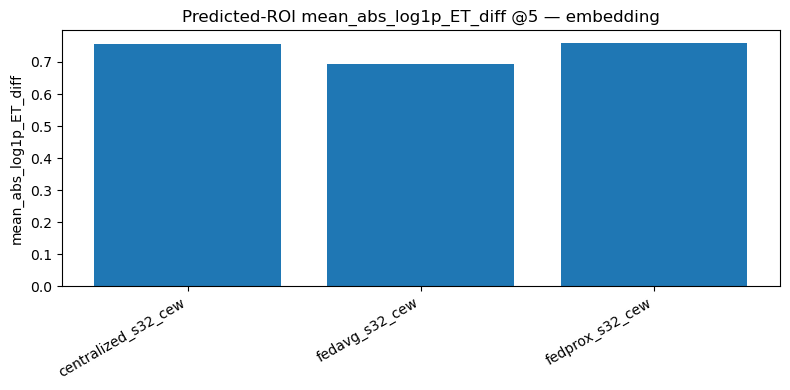

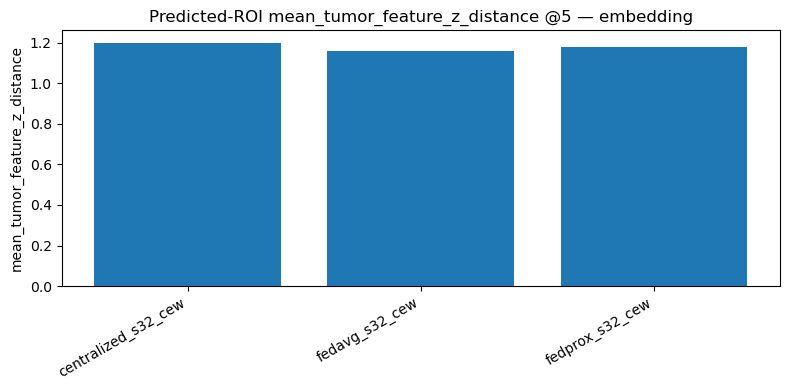

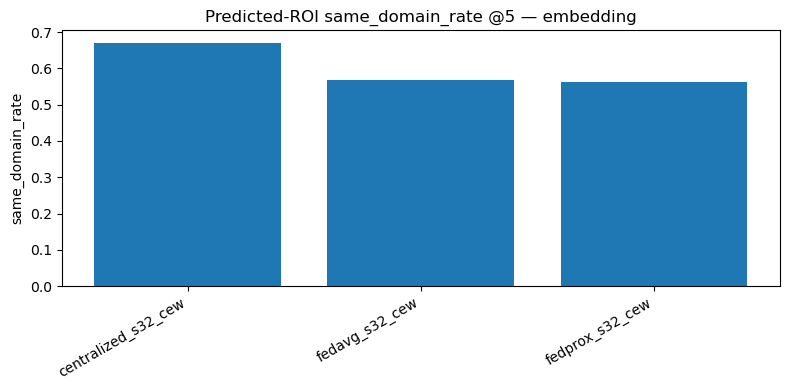

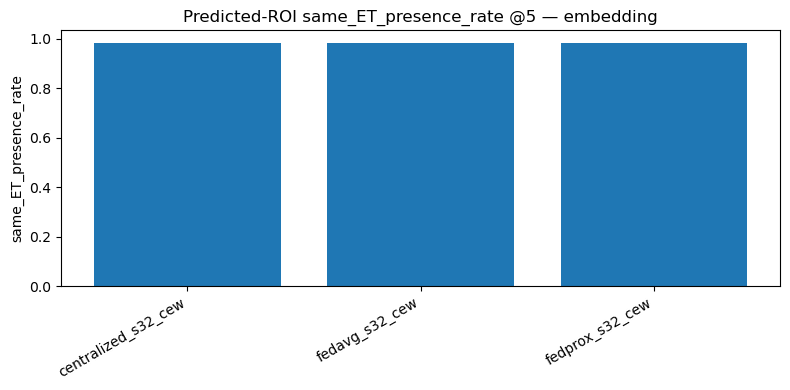

saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/17_figure_paths.csv


PosixPath('/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/17_figure_paths.csv')

In [22]:


def plot_bar_metric(df, metric, retrieval_space="embedding", k=5, save_name=None):
    d = df[
        (df["retrieval_space"] == retrieval_space)
        & (df["k"].astype(int) == int(k))
    ].copy()

    if len(d) == 0:
        print("No data for", metric, retrieval_space, k)
        return None, None

    x = np.arange(len(d))
    y = d[metric].astype(float).values
    labels = d["experiment_key"].astype(str).values

    plt.figure(figsize=(8, 4))
    plt.bar(x, y)
    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel(metric)
    plt.title(f"Predicted-ROI {metric} @{k} — {retrieval_space}")
    plt.tight_layout()

    if save_name is None:
        save_name = f"pred_roi_{metric}_k{k}_{retrieval_space}"

    png = FIGURE_DIR / f"{save_name}.png"
    pdf = FIGURE_DIR / f"{save_name}.pdf"
    plt.savefig(png, dpi=200, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    plt.show()

    return png, pdf


fig_rows = []
for metric in [
    "mean_abs_log1p_ET_diff",
    "mean_tumor_feature_z_distance",
    "same_domain_rate",
    "same_ET_presence_rate",
]:
    png, pdf = plot_bar_metric(overall_metrics_df, metric=metric, retrieval_space="embedding", k=5)
    if png is not None:
        fig_rows.append({"metric": metric, "png": str(png), "pdf": str(pdf)})

figure_df = pd.DataFrame(fig_rows)
save_dataframe(figure_df, "17_figure_paths")

## Retrieval report

In [23]:


def get_overall_metric(exp_key, space, k, metric):
    rows = overall_metrics_df[
        (overall_metrics_df["experiment_key"] == exp_key)
        & (overall_metrics_df["retrieval_space"] == space)
        & (overall_metrics_df["k"].astype(int) == int(k))
    ]

    if rows.empty:
        return np.nan

    return float(rows[metric].iloc[0])


report_k = 5 if 5 in CFG["top_k"] else int(CFG["top_k"][0])
report_space = "embedding"


# Dataset summary
domain_counts_df = (
    eval_df.groupby("client_domain")
    .size()
    .reset_index(name="Patients")
    .rename(columns={"client_domain": "Domain"})
)


# Predicted-ROI retrieval summary
summary_rows = []

for exp in enabled_experiments:
    key = exp["key"]

    center_diag = pred_roi_diag_df[
        pred_roi_diag_df["experiment_key"] == key
    ]

    if center_diag.empty:
        fallback_rate = np.nan
        mean_center_dist = np.nan
        median_center_dist = np.nan
    else:
        fallback_rate = float(
            (~center_diag["pred_has_WT"]).mean()
        )

        center_dist = center_diag[
            "pred_to_gt_wt_center_distance"
        ].astype(float)

        mean_center_dist = float(center_dist.mean())
        median_center_dist = float(center_dist.median())

    summary_rows.append(
        {
            "Model": exp["name"],
            "ET consistency": get_overall_metric(
                key,
                report_space,
                report_k,
                "same_ET_presence_rate",
            ),
            "WT volume diff": get_overall_metric(
                key,
                report_space,
                report_k,
                "mean_abs_log1p_WT_diff",
            ),
            "TC volume diff": get_overall_metric(
                key,
                report_space,
                report_k,
                "mean_abs_log1p_TC_diff",
            ),
            "ET volume diff": get_overall_metric(
                key,
                report_space,
                report_k,
                "mean_abs_log1p_ET_diff",
            ),
            "Tumor z-distance": get_overall_metric(
                key,
                report_space,
                report_k,
                "mean_tumor_feature_z_distance",
            ),
            "Same-domain rate": get_overall_metric(
                key,
                report_space,
                report_k,
                "same_domain_rate",
            ),
            "Same-domain enrichment": get_overall_metric(
                key,
                report_space,
                report_k,
                "same_domain_enrichment",
            ),
            "No-WT fallback rate": fallback_rate,
            "Mean center distance": mean_center_dist,
            "Median center distance": median_center_dist,
        }
    )


retrieval_summary_df = pd.DataFrame(summary_rows)

retrieval_summary_df = retrieval_summary_df.round(
    {
        "ET consistency": 4,
        "WT volume diff": 4,
        "TC volume diff": 4,
        "ET volume diff": 4,
        "Tumor z-distance": 4,
        "Same-domain rate": 4,
        "Same-domain enrichment": 4,
        "No-WT fallback rate": 4,
        "Mean center distance": 3,
        "Median center distance": 3,
    }
)


# Predicted-ROI vs GT-centered comparison
roi_delta_report_df = pd.DataFrame()

if roi_comparison_df is not None and not roi_comparison_df.empty:
    comp = roi_comparison_df[
        (roi_comparison_df["retrieval_space"] == report_space)
        & (roi_comparison_df["k"].astype(int) == report_k)
    ].copy()

    delta_columns = [
        "mean_abs_log1p_WT_diff_delta_pred_minus_gt",
        "mean_abs_log1p_TC_diff_delta_pred_minus_gt",
        "mean_abs_log1p_ET_diff_delta_pred_minus_gt",
        "mean_tumor_feature_z_distance_delta_pred_minus_gt",
        "same_domain_rate_delta_pred_minus_gt",
    ]

    available_delta_columns = [
        col
        for col in delta_columns
        if col in comp.columns
    ]

    keep_columns = [
        "experiment_key",
        *available_delta_columns,
    ]

    roi_delta_report_df = comp[keep_columns].copy()

    roi_delta_report_df = roi_delta_report_df.rename(
        columns={
            "experiment_key": "Experiment",
            "mean_abs_log1p_WT_diff_delta_pred_minus_gt": "WT diff delta",
            "mean_abs_log1p_TC_diff_delta_pred_minus_gt": "TC diff delta",
            "mean_abs_log1p_ET_diff_delta_pred_minus_gt": "ET diff delta",
            "mean_tumor_feature_z_distance_delta_pred_minus_gt": "Tumor z-distance delta",
            "same_domain_rate_delta_pred_minus_gt": "Same-domain rate delta",
        }
    )

    numeric_cols = [
        col
        for col in roi_delta_report_df.columns
        if col != "Experiment"
    ]

    roi_delta_report_df[numeric_cols] = (
        roi_delta_report_df[numeric_cols]
        .astype(float)
        .round(4)
    )


report_parts = [
    "# 08c Predicted-mask ROI Static Digital Twin Retrieval Report",
    "",
    "## Evaluation setup",
    "",
    f"- Split: `{CFG['split_filter']}`",
    f"- Patients: `{len(eval_df)}`",
    f"- ROI source: `{CFG['roi_source']}`",
    f"- Fallback if predicted WT is empty: `{CFG['fallback_if_no_pred_wt']}`",
    f"- GT fallback allowed: `{CFG['allow_gt_fallback']}`",
    f"- Retrieval space used for the primary summary: `{report_space}`",
    f"- k: `{report_k}`",
    "",
    "## Domain counts",
    "",
    domain_counts_df.to_markdown(index=False),
    "",
    f"## Predicted-ROI embedding retrieval at k={report_k}",
    "",
    retrieval_summary_df.to_markdown(index=False),
    "",
]


if not roi_delta_report_df.empty:
    report_parts.extend(
        [
            "## Predicted ROI vs GT-centered ROI",
            "",
            (
                "Values are predicted-ROI metrics minus the corresponding "
                "GT-centered ROI metrics."
            ),
            "",
            roi_delta_report_df.to_markdown(index=False),
            "",
        ]
    )


report_parts.extend(
    [
        "## Method notes",
        "",
        (
            "- Predicted WT determines ROI localization; ground-truth "
            "segmentation is not used to select the ROI."
        ),
        (
            "- Ground-truth tumor features are used only to evaluate "
            "phenotype similarity of retrieved neighbors."
        ),
        (
            "- `embedding` uses the SegResNet encoder representation."
        ),
        (
            "- `pred_tumor_features` uses phenotype features derived from "
            "the predicted segmentation mask."
        ),
        (
            "- `hybrid_pred_features` combines the encoder representation "
            "with prediction-derived tumor features."
        ),
        (
            "- Predicted-to-GT center distance is reported as an ROI "
            "localization diagnostic."
        ),
        "",
        "## Outputs",
        "",
        f"- Tables: `{TABLE_DIR}`",
        f"- Embeddings: `{EMBED_DIR}`",
        f"- Reports: `{REPORT_DIR}`",
        "",
    ]
)


report_text = "\n".join(report_parts)

report_path = (
    REPORT_DIR
    / "08c_predicted_mask_roi_retrieval_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

display(Markdown(report_text))
print("saved report:", report_path)

# 08c Predicted-mask ROI Static Digital Twin Retrieval Report

## Evaluation setup

- Split: `['test']`
- Patients: `211`
- ROI source: `predicted_wt_center`
- Fallback if predicted WT is empty: `image_foreground_center`
- GT fallback allowed: `False`
- Retrieval space used for the primary summary: `embedding`
- k: `5`

## Domain counts

| Domain    |   Patients |
|:----------|-----------:|
| TCGA-GBM  |         20 |
| TCGA-LGG  |         13 |
| UCSF-PDGM |         76 |
| UPENN-GBM |        102 |

## Predicted-ROI embedding retrieval at k=5

| Model                                            |   ET consistency |   WT volume diff |   TC volume diff |   ET volume diff |   Tumor z-distance |   Same-domain rate |   Same-domain enrichment |   No-WT fallback rate |   Mean center distance |   Median center distance |
|:-------------------------------------------------|-----------------:|-----------------:|-----------------:|-----------------:|-------------------:|-------------------:|-------------------------:|----------------------:|-----------------------:|-------------------------:|
| Centralized SegResNet32 final CE-weighted — TEST |           0.9848 |           0.5715 |           0.633  |           0.7549 |             1.2    |             0.6711 |                   2.4306 |                     0 |                  1.937 |                    1.414 |
| FedAvg SegResNet32 final CE-weighted — TEST      |           0.9848 |           0.4693 |           0.587  |           0.6925 |             1.1561 |             0.5678 |                   1.7661 |                     0 |                  2.468 |                    1.414 |
| FedProx SegResNet32 final CE-weighted — TEST     |           0.981  |           0.4996 |           0.5998 |           0.7608 |             1.1799 |             0.5611 |                   1.7434 |                     0 |                  2.53  |                    1.414 |

## Predicted ROI vs GT-centered ROI

Values are predicted-ROI metrics minus the corresponding GT-centered ROI metrics.

| Experiment          |   WT diff delta |   TC diff delta |   ET diff delta |   Tumor z-distance delta |   Same-domain rate delta |
|:--------------------|----------------:|----------------:|----------------:|-------------------------:|-------------------------:|
| centralized_s32_cew |          0.003  |          0.0019 |          0.0045 |                   0.0028 |                  -0.0085 |
| fedavg_s32_cew      |          0.0162 |          0.0096 |          0.0057 |                  -0.0005 |                  -0.0019 |
| fedprox_s32_cew     |         -0.01   |          0.0006 |          0.0075 |                  -0.0045 |                   0.0066 |

## Method notes

- Predicted WT determines ROI localization; ground-truth segmentation is not used to select the ROI.
- Ground-truth tumor features are used only to evaluate phenotype similarity of retrieved neighbors.
- `embedding` uses the SegResNet encoder representation.
- `pred_tumor_features` uses phenotype features derived from the predicted segmentation mask.
- `hybrid_pred_features` combines the encoder representation with prediction-derived tumor features.
- Predicted-to-GT center distance is reported as an ROI localization diagnostic.

## Outputs

- Tables: `/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables`
- Embeddings: `/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/embeddings`
- Reports: `/home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/reports`


saved report: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/reports/08c_predicted_mask_roi_retrieval_report.md


## Output validation

In [24]:


split_filter = CFG["split_filter"]

if isinstance(split_filter, str):
    split_is_test = split_filter == "test"
else:
    split_is_test = list(split_filter) == ["test"]


gt_fallback_used = (
    pred_roi_diag_df["roi_source_used"]
    .astype(str)
    .str.contains(
        "gt_wt_center",
        case=False,
        regex=False,
    )
    .any()
)


checks = {
    "test_split": split_is_test,
    "gt_fallback_disabled": CFG["allow_gt_fallback"] is False,
    "gt_fallback_not_used": not gt_fallback_used,
    "features_complete": len(features_df) == len(eval_df),
    "embeddings_complete": (
        len(embeddings_by_exp) == len(enabled_experiments)
    ),
    "embedding_integrity": bool(
        integrity_df["all_finite"].all()
        and integrity_df["patient_order_aligned"].all()
    ),
    "neighbors_available": not neighbors_df.empty,
    "overall_metrics_available": not overall_metrics_df.empty,
    "domain_metrics_available": not domain_metrics_df.empty,
    "roi_diagnostics_available": not pred_roi_diag_df.empty,
    "report_saved": report_path.exists(),
}

checks["complete"] = all(checks.values())


checks_df = pd.DataFrame([checks])

safe_display(
    "08c output checks",
    checks_df,
)

save_dataframe(
    checks_df,
    "19_output_checks",
)


run_manifest = {
    "cfg": CFG,
    "project_root": str(PROJECT_ROOT),
    "output_dir": str(OUT_DIR),
    "n_eval": int(len(eval_df)),
    "device": str(device),
    "use_amp": bool(use_amp),
    "experiments": [
        exp["key"]
        for exp in enabled_experiments
    ],
    "outputs": {
        "tables": str(TABLE_DIR),
        "embeddings": str(EMBED_DIR),
        "figures": str(FIGURE_DIR),
        "reports": str(REPORT_DIR),
        "logs": str(LOG_DIR),
    },
    "checks": checks,
}

run_manifest_path = (
    LOG_DIR
    / "08c_run_manifest.json"
)

save_json(
    run_manifest,
    run_manifest_path,
)

print("saved run manifest:", run_manifest_path)


if checks["complete"]:
    display(
        Markdown(
            "**PASS:** all expected 08c outputs are available "
            "and no GT ROI fallback was used."
        )
    )
else:
    failed = [
        name
        for name, passed in checks.items()
        if name != "complete" and not passed
    ]

    display(
        Markdown(
            "**FAIL:** missing or invalid checks: "
            + ", ".join(f"`{name}`" for name in failed)
        )
    )

### 08c output checks

,test_split,gt_fallback_disabled,gt_fallback_not_used,features_complete,embeddings_complete,embedding_integrity,neighbors_available,overall_metrics_available,domain_metrics_available,roi_diagnostics_available,report_saved,complete
0,True,True,True,True,True,True,True,True,True,True,True,True


saved: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/19_output_checks.csv
saved run manifest: /home/mandrakedrink/projects/research_ts_bs/docs/08c_predicted_mask_roi_embedding_retrieval_test/logs/08c_run_manifest.json


**PASS:** all expected 08c outputs are available and no GT ROI fallback was used.